In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler
import os

mpl.rcParams["axes.prop_cycle"] = cycler(
    color=[
        "#D3A400",
        "#008AB2",
        "#30B87F",
    ]
)
colour_scheme = {
    "ASTRA better": "#D3A400",
    "Same": "#008AB2",
    "ASTRA worse": "#30B87F",
    "Gains": "#D3A400",
    "Losses": "#30B87F",
    "Total": "#D0385E",
}
plt.rcParams["font.family"] = ["DejaVu Sans Mono"]
plt.rcParams.update({"font.size": 10})
os.makedirs("figures", exist_ok=True)
cm = 1 / 2.54

# Synthetic Data

In [2]:
import os
import pickle
from scipy.stats import wilcoxon

In [3]:
def plot_results(results_dict: dict, classification: bool = False):
    """
    Plot benchmark results.

    Parameters
    ----------
    results_dict : dict
        Dictionary containing benchmark results.
    classification : bool, optional
        Whether the results are for classification tasks, by default False.
    """
    fig, ax = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    outperformance_counts_mean = {"ASTRA better": 0, "Same": 0, "ASTRA worse": 0}
    outperformance_counts_median = {"ASTRA better": 0, "Same": 0, "ASTRA worse": 0}
    for dataset in results_dict:
        astra_score = results_dict[dataset]["ASTRA"]
        best_mean_score = results_dict[dataset]["Mean"]
        best_median_score = results_dict[dataset]["Median"]
        if classification:  # higher is better
            delta_mean = astra_score - best_mean_score
            delta_median = astra_score - best_median_score
        else:  # lower is better
            delta_mean = best_mean_score - astra_score
            delta_median = best_median_score - astra_score
        if delta_mean > 0:
            outperformance_counts_mean["ASTRA better"] += 1
        elif delta_mean == 0:
            outperformance_counts_mean["Same"] += 1
        else:
            outperformance_counts_mean["ASTRA worse"] += 1
        if delta_median > 0:
            outperformance_counts_median["ASTRA better"] += 1
        elif delta_median == 0:
            outperformance_counts_median["Same"] += 1
        else:
            outperformance_counts_median["ASTRA worse"] += 1
    ax[0].bar(
        outperformance_counts_mean.keys(),
        outperformance_counts_mean.values(),
        color=[colour_scheme[key] for key in outperformance_counts_mean.keys()],
    )
    print(outperformance_counts_mean)
    ax[0].set_ylabel("Number of experiments")
    ax[0].set_title("ASTRA vs. best mean")
    ax[1].bar(
        outperformance_counts_median.keys(),
        outperformance_counts_median.values(),
        color=[colour_scheme[key] for key in outperformance_counts_median.keys()],
    )
    print(outperformance_counts_median)
    ax[1].set_ylabel("Number of experiments")
    ax[1].set_title("ASTRA vs. best median")
    plt.tight_layout()
    plt.savefig(
        f"figures/synthetic_data_{'classification' if classification else 'regression'}.png",
        dpi=300,
    )
    plt.show()


def plot_results_quantitative(results_dict: dict, classification: bool = False):
    """
    Plot benchmark results.

    Parameters
    ----------
    results_dict : dict
        Dictionary containing benchmark results.
    classification : bool, optional
        Whether the results are for classification tasks, by default False.
    """
    fig, ax = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    difference_mean = {"Gains": 0, "Losses": 0, "Total": 0}
    denominator_mean = {"Gains": 0, "Losses": 0, "Total": 0}
    difference_median = {"Gains": 0, "Losses": 0, "Total": 0}
    denominator_median = {"Gains": 0, "Losses": 0, "Total": 0}
    all_scores_astra = []
    all_scores_best_mean = []
    all_scores_best_median = []
    for dataset in results_dict:
        astra_score = results_dict[dataset]["ASTRA"]
        all_scores_astra.append(astra_score)
        best_mean_score = results_dict[dataset]["Mean"]
        all_scores_best_mean.append(best_mean_score)
        best_median_score = results_dict[dataset]["Median"]
        all_scores_best_median.append(best_median_score)
        if classification:  # higher is better
            delta_mean = astra_score - best_mean_score
            delta_median = astra_score - best_median_score
        else:  # lower is better
            delta_mean = (best_mean_score - astra_score) / best_mean_score * 100
            delta_median = (best_median_score - astra_score) / best_median_score * 100
        if delta_mean > 0:
            difference_mean["Gains"] += delta_mean
            denominator_mean["Gains"] += 1
            difference_mean["Total"] += delta_mean
            denominator_mean["Total"] += 1
        elif delta_mean < 0:
            difference_mean["Losses"] += delta_mean
            denominator_mean["Losses"] += 1
            difference_mean["Total"] += delta_mean
            denominator_mean["Total"] += 1
        else:
            denominator_mean["Total"] += 1
        if delta_median > 0:
            difference_median["Gains"] += delta_median
            denominator_median["Gains"] += 1
            difference_median["Total"] += delta_median
            denominator_median["Total"] += 1
        elif delta_median < 0:
            difference_median["Losses"] += delta_median
            denominator_median["Losses"] += 1
            difference_median["Total"] += delta_median
            denominator_median["Total"] += 1
        else:
            denominator_median["Total"] += 1
    for key in difference_mean:
        difference_mean[key] /= denominator_mean[key]
    for key in difference_median:
        difference_median[key] /= denominator_median[key]
    ax[0].bar(
        difference_mean.keys(),
        difference_mean.values(),
        color=[colour_scheme[key] for key in difference_mean.keys()],
    )
    print(difference_mean)
    ylabel = "Mean AUROC change" if classification else "Mean relative MSE change [%]"
    ax[0].set_ylabel(ylabel)
    ax[0].set_title("ASTRA vs. best mean")
    ax[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax[1].bar(
        difference_median.keys(),
        difference_median.values(),
        color=[colour_scheme[key] for key in difference_median.keys()],
    )
    print(difference_median)
    ax[1].set_ylabel(ylabel)
    ax[1].set_title("ASTRA vs. best median")
    ax[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.savefig(
        f"figures/synthetic_data_quantitative{'classification' if classification else 'regression'}.png",
        dpi=300,
    )
    # significance testing
    _, p_value_mean = wilcoxon(
        all_scores_astra,
        all_scores_best_mean,
        alternative="greater" if classification else "less",
        zero_method="pratt",
    )
    _, p_value_median = wilcoxon(
        all_scores_astra,
        all_scores_best_median,
        alternative="greater" if classification else "less",
        zero_method="pratt",
    )
    print(
        f"One-sided (alternative {'greater' if classification else 'less'}) Wilcoxon signed-rank test (mean): p-value={p_value_mean}"
    )
    print(
        f"One-sided (alternative {'greater' if classification else 'less'}) Wilcoxon signed-rank test (median): p-value={p_value_median}"
    )
    _, p_value_mean = wilcoxon(
        all_scores_astra,
        all_scores_best_mean,
        alternative="less" if classification else "greater",
        zero_method="pratt",
    )
    _, p_value_median = wilcoxon(
        all_scores_astra,
        all_scores_best_median,
        alternative="less" if classification else "greater",
        zero_method="pratt",
    )
    print(
        f"One-sided (alternative {'less' if classification else 'greater'}) Wilcoxon signed-rank test (mean): p-value={p_value_mean}"
    )
    print(
        f"One-sided (alternative {'less' if classification else 'greater'}) Wilcoxon signed-rank test (median): p-value={p_value_median}"
    )
    _, p_value_mean = wilcoxon(
        all_scores_astra,
        all_scores_best_mean,
        zero_method="pratt",
    )
    _, p_value_median = wilcoxon(
        all_scores_astra,
        all_scores_best_median,
        zero_method="pratt",
    )
    print(f"Regular Wilcoxon signed-rank test (mean): p-value={p_value_mean}")
    print(f"Regular Wilcoxon signed-rank test (median): p-value={p_value_median}")
    plt.show()

In [4]:
with open("results/classification_results_syn.pkl", "rb") as f:
    classification_results = pickle.load(f)
len(classification_results)

531

{'ASTRA better': 41, 'Same': 452, 'ASTRA worse': 38}
{'ASTRA better': 62, 'Same': 426, 'ASTRA worse': 43}


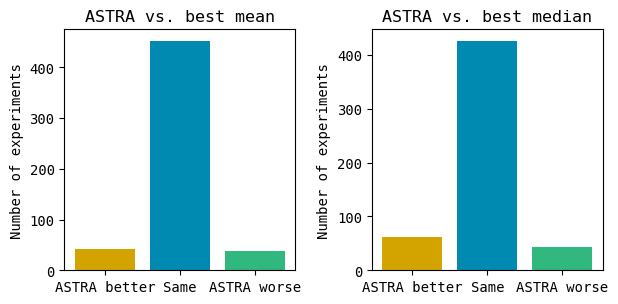

In [5]:
plot_results(classification_results, classification=True)

{'Gains': 0.06565789051211557, 'Losses': -0.06806852289548786, 'Total': 0.00019843623534500766}
{'Gains': 0.06651755775772235, 'Losses': -0.06116266917373197, 'Total': 0.0028137359821248796}
One-sided (alternative greater) Wilcoxon signed-rank test (mean): p-value=0.37828765701940614
One-sided (alternative greater) Wilcoxon signed-rank test (median): p-value=0.028548864834850286
One-sided (alternative less) Wilcoxon signed-rank test (mean): p-value=0.6217123429805939
One-sided (alternative less) Wilcoxon signed-rank test (median): p-value=0.9714511351651497
Regular Wilcoxon signed-rank test (mean): p-value=0.7565753140388123
Regular Wilcoxon signed-rank test (median): p-value=0.05709772966970057


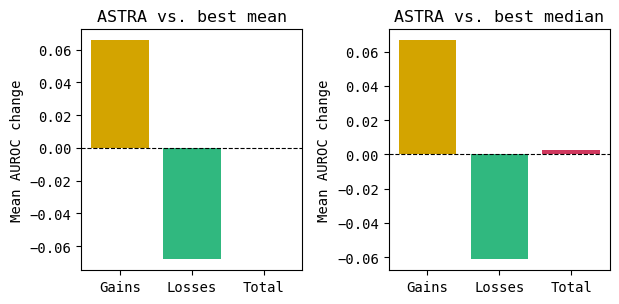

In [6]:
plot_results_quantitative(classification_results, classification=True)

In [7]:
with open("results/regression_results_syn.pkl", "rb") as f:
    regression_results = pickle.load(f)
len(regression_results)

432

{'ASTRA better': 22, 'Same': 377, 'ASTRA worse': 33}
{'ASTRA better': 13, 'Same': 395, 'ASTRA worse': 24}


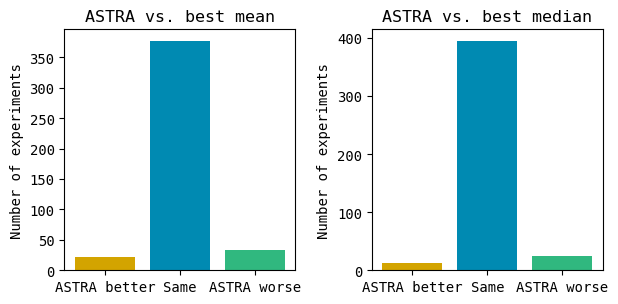

In [8]:
plot_results(regression_results, classification=False)

{'Gains': 8.820227529151815, 'Losses': -13.308722327211262, 'Total': -0.567460257307018}
{'Gains': 5.17585128320709, 'Losses': -26.18841706978949, 'Total': -1.299157275447351}
One-sided (alternative less) Wilcoxon signed-rank test (mean): p-value=0.9364141355519098
One-sided (alternative less) Wilcoxon signed-rank test (median): p-value=0.9667309655760015
One-sided (alternative greater) Wilcoxon signed-rank test (mean): p-value=0.06358586444809021
One-sided (alternative greater) Wilcoxon signed-rank test (median): p-value=0.0332690344239985
Regular Wilcoxon signed-rank test (mean): p-value=0.12717172889618042
Regular Wilcoxon signed-rank test (median): p-value=0.066538068847997


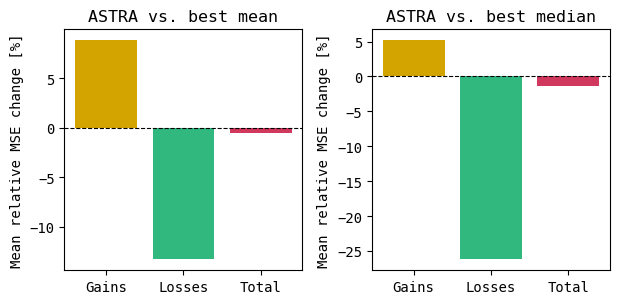

In [9]:
plot_results_quantitative(regression_results, classification=False)

# ASAP Discovery x OpenADMET Challenge

## Dataset splits

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
no_datapoints_per_fold = {}
for dataset in ["MDR1_MDCKII", "HLM", "KSOL", "MLM", "LogD", "MERS", "SARS"]:
    no_datapoints_per_fold[dataset] = {}
    df = pd.read_pickle(f"processed_data/{dataset}_train_splits.pkl")
    for random_seed in [42, 7, 21, 100, 1234]:
        for clustering_type in ["Random", "Butina", "BemisMurcko", "KMeans"]:
            no_datapoints_per_fold[dataset][
                f"{clustering_type}_Cluster_{random_seed}"
            ] = []
            results = (
                df[f"{clustering_type}_Cluster_{random_seed}"]
                .value_counts()
                .sort_index()
            )
            for fold in range(5):
                no_datapoints_per_fold[dataset][
                    f"{clustering_type}_Cluster_{random_seed}"
                ].append(int(results[fold]))

In [8]:
# check which seed leads to the most balanced splits for each clustering type and dataset
best_seeds = {}
for dataset in no_datapoints_per_fold:
    best_seeds[dataset] = {}
    for clustering_type in ["Butina", "BemisMurcko", "KMeans"]:
        seed_std = {}
        for random_seed in [42, 7, 21, 100, 1234]:
            seed_std[random_seed] = pd.Series(
                no_datapoints_per_fold[dataset][
                    f"{clustering_type}_Cluster_{random_seed}"
                ]
            ).std()
        best_seed = min(seed_std, key=seed_std.get)
        best_seeds[dataset][clustering_type] = best_seed
        print(
            f"Dataset: {dataset}, Clustering: {clustering_type}, Best Seed: {best_seed}, Std: {seed_std[best_seed]:.2f}"
        )

Dataset: MDR1_MDCKII, Clustering: Butina, Best Seed: 21, Std: 16.54
Dataset: MDR1_MDCKII, Clustering: BemisMurcko, Best Seed: 100, Std: 9.14
Dataset: MDR1_MDCKII, Clustering: KMeans, Best Seed: 100, Std: 11.85
Dataset: HLM, Clustering: Butina, Best Seed: 100, Std: 20.69
Dataset: HLM, Clustering: BemisMurcko, Best Seed: 7, Std: 8.41
Dataset: HLM, Clustering: KMeans, Best Seed: 1234, Std: 8.47
Dataset: KSOL, Clustering: Butina, Best Seed: 7, Std: 20.33
Dataset: KSOL, Clustering: BemisMurcko, Best Seed: 1234, Std: 9.64
Dataset: KSOL, Clustering: KMeans, Best Seed: 100, Std: 7.94
Dataset: MLM, Clustering: Butina, Best Seed: 21, Std: 21.05
Dataset: MLM, Clustering: BemisMurcko, Best Seed: 1234, Std: 10.11
Dataset: MLM, Clustering: KMeans, Best Seed: 100, Std: 4.34
Dataset: LogD, Clustering: Butina, Best Seed: 7, Std: 22.61
Dataset: LogD, Clustering: BemisMurcko, Best Seed: 21, Std: 6.99
Dataset: LogD, Clustering: KMeans, Best Seed: 42, Std: 7.37
Dataset: MERS, Clustering: Butina, Best Seed:

## Analyse results for `astra benchmark`

In [10]:
import pickle
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

In [11]:
def plot_astra_benchmark_results(results: list[dict], subset: str | None = None):
    """
    Plot results of ASTRA benchmark.

    Parameters
    ----------
    results : list[dict]
        List of dictionaries containing benchmark results.
    subset : str | None, optional
        Subset of results to consider, by default None. Must be 'significant' or 'insignificant'.
    """
    assert subset in (None, "significant", "insignificant"), (
        "subset must be 'significant', 'insignificant', or None"
    )
    fig, ax = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    outperformance_counts_mean = {"ASTRA better": 0, "Same": 0, "ASTRA worse": 0}
    outperformance_counts_median = {"ASTRA better": 0, "Same": 0, "ASTRA worse": 0}
    for result in results:
        for split in ["random", "butina", "bemismurcko", "kmeans"]:
            for feat in result:
                if subset == "insignificant" and result[feat][split]["p-value"] < 0.05:
                    continue
                if subset == "significant" and result[feat][split]["p-value"] >= 0.05:
                    continue
                mse_astra = result[feat][split]["ASTRA"]
                mse_best_mean = result[feat][split]["Mean"]
                mse_best_median = result[feat][split]["Median"]
                outperforms_mean = mse_astra < mse_best_mean
                matches_mean = mse_astra == mse_best_mean
                outperforms_median = mse_astra < mse_best_median
                matches_median = mse_astra == mse_best_median
                if outperforms_mean:
                    outperformance_counts_mean["ASTRA better"] += 1
                elif matches_mean:
                    outperformance_counts_mean["Same"] += 1
                else:
                    outperformance_counts_mean["ASTRA worse"] += 1
                if outperforms_median:
                    outperformance_counts_median["ASTRA better"] += 1
                elif matches_median:
                    outperformance_counts_median["Same"] += 1
                else:
                    outperformance_counts_median["ASTRA worse"] += 1
    ax[0].bar(
        outperformance_counts_mean.keys(),
        outperformance_counts_mean.values(),
        color=[colour_scheme[key] for key in outperformance_counts_mean.keys()],
    )
    print(outperformance_counts_mean)
    ax[0].set_ylabel("Number of experiments")
    ax[0].set_title("ASTRA vs. best mean")
    ax[1].bar(
        outperformance_counts_median.keys(),
        outperformance_counts_median.values(),
        color=[colour_scheme[key] for key in outperformance_counts_median.keys()],
    )
    print(outperformance_counts_median)
    ax[1].set_ylabel("Number of experiments")
    ax[1].set_title("ASTRA vs. best median")
    plt.tight_layout()
    plt.savefig(
        f"figures/astra_benchmark{'_' + subset if subset is not None else ''}.png",
        dpi=300,
    )
    plt.show()

In [12]:
def plot_astra_benchmark_results_quantitative(
    results: list[dict], subset: str | None = None
):
    """
    Plot results of ASTRA benchmark.

    Parameters
    ----------
    results : list[dict]
        List of dictionaries containing benchmark results.
    subset : str | None, optional
        Subset of results to consider, by default None. Must be 'significant' or 'insignificant'.
    """
    assert subset in (None, "significant", "insignificant"), (
        "subset must be 'significant', 'insignificant', or None"
    )
    fig, ax = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    difference_mean = {"Gains": 0, "Losses": 0, "Total": 0}
    denominator_mean = {"Gains": 0, "Losses": 0, "Total": 0}
    difference_median = {"Gains": 0, "Losses": 0, "Total": 0}
    denominator_median = {"Gains": 0, "Losses": 0, "Total": 0}
    all_mses_astra = []
    all_mses_best_mean = []
    all_mses_best_median = []
    for result in results:
        for split in ["random", "butina", "bemismurcko", "kmeans"]:
            for feat in result:
                if subset == "insignificant" and result[feat][split]["p-value"] < 0.05:
                    continue
                if subset == "significant" and result[feat][split]["p-value"] >= 0.05:
                    continue
                mse_astra = result[feat][split]["ASTRA"]
                all_mses_astra.append(mse_astra)
                mse_best_mean = result[feat][split]["Mean"]
                all_mses_best_mean.append(mse_best_mean)
                mse_best_median = result[feat][split]["Median"]
                all_mses_best_median.append(mse_best_median)
                delta_mean = (mse_best_mean - mse_astra) / mse_best_mean * 100
                delta_median = (mse_best_median - mse_astra) / mse_best_median * 100
                if delta_mean > 0:
                    difference_mean["Gains"] += delta_mean
                    denominator_mean["Gains"] += 1
                    difference_mean["Total"] += delta_mean
                    denominator_mean["Total"] += 1
                elif delta_mean < 0:
                    difference_mean["Losses"] += delta_mean
                    denominator_mean["Losses"] += 1
                    difference_mean["Total"] += delta_mean
                    denominator_mean["Total"] += 1
                else:
                    denominator_mean["Total"] += 1
                if delta_median > 0:
                    difference_median["Gains"] += delta_median
                    denominator_median["Gains"] += 1
                    difference_median["Total"] += delta_median
                    denominator_median["Total"] += 1
                elif delta_median < 0:
                    difference_median["Losses"] += delta_median
                    denominator_median["Losses"] += 1
                    difference_median["Total"] += delta_median
                    denominator_median["Total"] += 1
                else:
                    denominator_median["Total"] += 1
    for key in difference_mean:
        difference_mean[key] /= denominator_mean[key]
    for key in difference_median:
        difference_median[key] /= denominator_median[key]
    ax[0].bar(
        difference_mean.keys(),
        difference_mean.values(),
        color=[colour_scheme[key] for key in difference_mean.keys()],
    )
    print(difference_mean)
    ax[0].set_ylabel("Mean relative MSE change [%]")
    ax[0].set_title("ASTRA vs. best mean")
    ax[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax[1].bar(
        difference_median.keys(),
        difference_median.values(),
        color=[colour_scheme[key] for key in difference_median.keys()],
    )
    print(difference_median)
    ax[1].set_ylabel("Mean relative MSE change [%]")
    ax[1].set_title("ASTRA vs. best median")
    ax[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.savefig(
        f"figures/astra_benchmark_quantitative{'_' + subset if subset is not None else ''}.png",
        dpi=300,
    )
    # significance testing
    _, p_value_mean = wilcoxon(
        all_mses_astra, all_mses_best_mean, alternative="less", zero_method="pratt"
    )
    _, p_value_median = wilcoxon(
        all_mses_astra, all_mses_best_median, alternative="less", zero_method="pratt"
    )
    print(
        f"One-sided (alternative: less) Wilcoxon signed-rank test (mean): p-value={p_value_mean}"
    )
    print(
        f"One-sided (alternative: less) Wilcoxon signed-rank test (median): p-value={p_value_median}"
    )
    _, p_value_mean = wilcoxon(
        all_mses_astra, all_mses_best_mean, alternative="greater", zero_method="pratt"
    )
    _, p_value_median = wilcoxon(
        all_mses_astra, all_mses_best_median, alternative="greater", zero_method="pratt"
    )
    print(
        f"One-sided (alternative: greater) Wilcoxon signed-rank test (mean): p-value={p_value_mean}"
    )
    print(
        f"One-sided (alternative: greater) Wilcoxon signed-rank test (median): p-value={p_value_median}"
    )
    _, p_value_mean = wilcoxon(all_mses_astra, all_mses_best_mean, zero_method="pratt")
    _, p_value_median = wilcoxon(
        all_mses_astra, all_mses_best_median, zero_method="pratt"
    )
    print(f"Regular Wilcoxon signed-rank test (mean): p-value={p_value_mean}")
    print(f"Regular Wilcoxon signed-rank test (median): p-value={p_value_median}")
    plt.show()

{'ASTRA better': 54, 'Same': 237, 'ASTRA worse': 45}
{'ASTRA better': 86, 'Same': 175, 'ASTRA worse': 75}


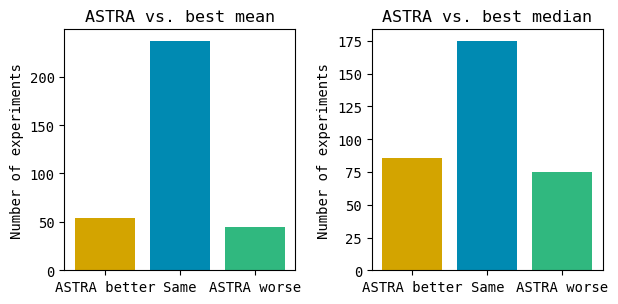

{'ASTRA better': 38, 'Same': 154, 'ASTRA worse': 24}
{'ASTRA better': 61, 'Same': 108, 'ASTRA worse': 47}


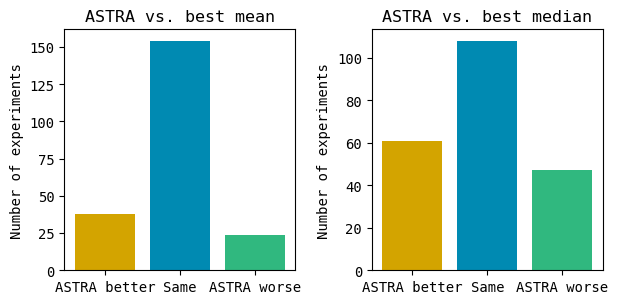

{'ASTRA better': 16, 'Same': 83, 'ASTRA worse': 21}
{'ASTRA better': 25, 'Same': 67, 'ASTRA worse': 28}


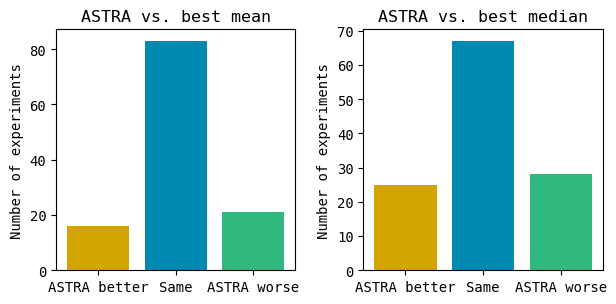

In [13]:
with open("results/LogD_results.pkl", "rb") as f:
    LogD_results = pickle.load(f)
with open("results/HLM_results.pkl", "rb") as f:
    HLM_results = pickle.load(f)
with open("results/KSOL_results.pkl", "rb") as f:
    KSOL_results = pickle.load(f)
with open("results/MDR1_MDCKII_results.pkl", "rb") as f:
    MDR1_MDCKII_results = pickle.load(f)
with open("results/MLM_results.pkl", "rb") as f:
    MLM_results = pickle.load(f)
with open("results/SARS_results.pkl", "rb") as f:
    SARS_results = pickle.load(f)
with open("results/MERS_results.pkl", "rb") as f:
    MERS_results = pickle.load(f)
plot_astra_benchmark_results(
    [
        LogD_results,
        HLM_results,
        KSOL_results,
        MDR1_MDCKII_results,
        MLM_results,
        SARS_results,
        MERS_results,
    ]
)
plot_astra_benchmark_results(
    [
        LogD_results,
        HLM_results,
        KSOL_results,
        MDR1_MDCKII_results,
        MLM_results,
        SARS_results,
        MERS_results,
    ],
    subset="insignificant",
)
plot_astra_benchmark_results(
    [
        LogD_results,
        HLM_results,
        KSOL_results,
        MDR1_MDCKII_results,
        MLM_results,
        SARS_results,
        MERS_results,
    ],
    subset="significant",
)

{'Gains': 12.222116551633771, 'Losses': -16.529795240949642, 'Total': -0.24954313111461385}
{'Gains': 12.400674685612113, 'Losses': -15.133541027071225, 'Total': -0.20404033948720376}
One-sided (alternative: less) Wilcoxon signed-rank test (mean): p-value=0.19672167943827878
One-sided (alternative: less) Wilcoxon signed-rank test (median): p-value=0.161335570415078
One-sided (alternative: greater) Wilcoxon signed-rank test (mean): p-value=0.8032783205617212
One-sided (alternative: greater) Wilcoxon signed-rank test (median): p-value=0.8386644295849219
Regular Wilcoxon signed-rank test (mean): p-value=0.39344335887655757
Regular Wilcoxon signed-rank test (median): p-value=0.322671140830156


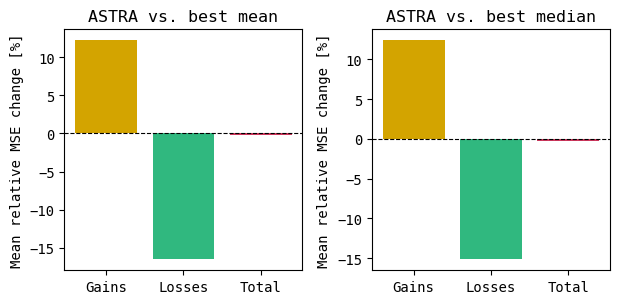

{'Gains': 13.452079107633299, 'Losses': -16.73299225044675, 'Total': 0.5073481114784408}
{'Gains': 14.101339424121464, 'Losses': -14.722117689199335, 'Total': 0.7788989512918559}
One-sided (alternative: less) Wilcoxon signed-rank test (mean): p-value=0.038041763062794956
One-sided (alternative: less) Wilcoxon signed-rank test (median): p-value=0.054687959810793926
One-sided (alternative: greater) Wilcoxon signed-rank test (mean): p-value=0.9619582369372051
One-sided (alternative: greater) Wilcoxon signed-rank test (median): p-value=0.9453120401892061
Regular Wilcoxon signed-rank test (mean): p-value=0.07608352612558991
Regular Wilcoxon signed-rank test (median): p-value=0.10937591962158785


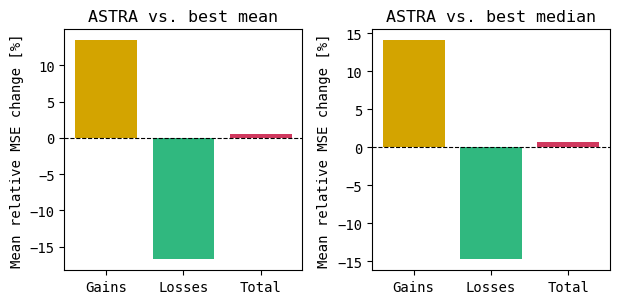

{'Gains': 9.3009554811349, 'Losses': -16.29757008723866, 'Total': -1.6119473677821121}
{'Gains': 8.251052723649295, 'Losses': -15.824144487070495, 'Total': -1.9733310628895109}
One-sided (alternative: less) Wilcoxon signed-rank test (mean): p-value=0.8278671273223339
One-sided (alternative: less) Wilcoxon signed-rank test (median): p-value=0.7180068459180924
One-sided (alternative: greater) Wilcoxon signed-rank test (mean): p-value=0.17213287267766614
One-sided (alternative: greater) Wilcoxon signed-rank test (median): p-value=0.28199315408190756
Regular Wilcoxon signed-rank test (mean): p-value=0.3442657453553323
Regular Wilcoxon signed-rank test (median): p-value=0.5639863081638151


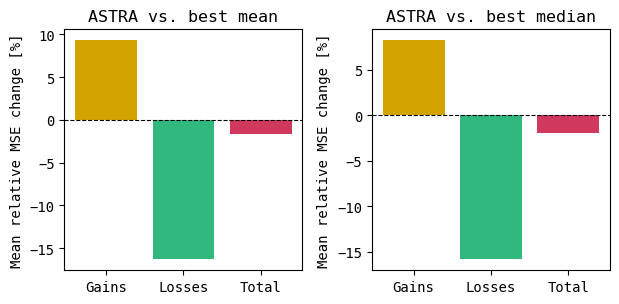

In [14]:
plot_astra_benchmark_results_quantitative(
    [
        LogD_results,
        HLM_results,
        KSOL_results,
        MDR1_MDCKII_results,
        MLM_results,
        SARS_results,
        MERS_results,
    ]
)
plot_astra_benchmark_results_quantitative(
    [
        LogD_results,
        HLM_results,
        KSOL_results,
        MDR1_MDCKII_results,
        MLM_results,
        SARS_results,
        MERS_results,
    ],
    subset="insignificant",
)
plot_astra_benchmark_results_quantitative(
    [
        LogD_results,
        HLM_results,
        KSOL_results,
        MDR1_MDCKII_results,
        MLM_results,
        SARS_results,
        MERS_results,
    ],
    subset="significant",
)

## Analyse results for `astra compare`

In [15]:
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error
from astra.utils import get_estimator_name

/u/fd/sjoh5775/miniconda3/envs/astra_benchmark/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
def get_CV_scores(dirs: list[str]) -> dict:
    """
    Get mean and median cross-validation scores for all models.

    Parameters
    ----------
    dirs : list[str]
        List of directories containing model results.

    Returns
    -------
    dict
        Dictionary of cross-validation scores for all models.
    """
    scores = {}
    for dir in dirs:
        with open(os.path.join(dir, "final_CV.pkl"), "rb") as f:
            cv_scores = pickle.load(f)
            mses = cv_scores["mse"]
            median = np.median(mses)
            mean = np.mean(mses)
            model_name = dir.split("/")[-1]
            scores[model_name] = {"mean": mean, "median": median}
    return scores


def get_test_score(model: str, test_X: np.ndarray, test_y: np.ndarray) -> float:
    """
    Get the test mean squared error for a given model.

    Parameters
    ----------
    model : str
        Path to the model pickle file.
    test_X : np.ndarray
        Test features.
    test_y : np.ndarray
        Test target values.

    Returns
    -------
    float
        Mean squared error on the test set.
    """
    with open(model, "rb") as f:
        estimator = pickle.load(f)
    predictions = estimator.predict(test_X)
    mse = mean_squared_error(test_y, predictions)
    return mse


def collect_all_test_scores(dirs: list[str], test_data: list[str]) -> dict:
    """
    Collect test mean squared errors for all models.

    Parameters
    ----------
    dirs : list[str]
        List of directories containing model results.
    test_data : list[str]
        List of paths to the test data pickle files.

    Returns
    -------
    dict
        Dictionary of test mean squared errors for all models.
    """
    test_scores = {}
    for dir, test_file in zip(dirs, test_data):
        model_name = dir.split("/")[-1]
        model_path = os.path.join(dir, "final_model.pkl")
        test_X_y = pd.read_pickle(test_file)
        X_test = np.array(test_X_y["Features"].to_list())
        y_test = test_X_y["Target"].values
        mse = get_test_score(model_path, X_test, y_test)
        test_scores[model_name] = mse
    return test_scores


def collect_results(
    dirs: list[str], test_data: list[str], astra_model: str
) -> tuple[float, float, float, float]:
    """
    Get MSEs of the best mean, best median and the ASTRA model, along with Spearman correlation p-value.

    Parameters
    ----------
    dirs : list[str]
        List of directories containing model results.
    test_data : list[str]
        List of paths to the test data pickle files.
    astra_model : str
        Name of the ASTRA model.

    Returns
    -------
    tuple[float, float, float, float]
        MSEs of best mean model, best median model, and ASTRA model,
        and Spearman correlation p-value.
    """
    CV_scores = get_CV_scores(dirs)
    test_scores = collect_all_test_scores(dirs, test_data)
    _, p_value = spearmanr(
        [CV_scores[model]["median"] for model in CV_scores],
        [test_scores[model] for model in test_scores],
    )
    best_mean_model = min(CV_scores, key=lambda x: CV_scores[x]["mean"])
    best_median_model = min(CV_scores, key=lambda x: CV_scores[x]["median"])
    mse_astra = test_scores[astra_model]
    mse_best_mean = test_scores[best_mean_model]
    mse_best_median = test_scores[best_median_model]
    return mse_best_mean, mse_best_median, mse_astra, p_value


def plot_astra_compare_results(
    mses_average: list[float],
    mses_median: list[float],
    mses_astra: list[float],
    pvals: list[float],
    subset: str | None = None,
):
    """
    Plot benchmark results.

    Parameters
    ----------
    mses_average : list[float]
        List of MSEs of best mean models.
    mses_median : list[float]
        List of MSEs of best median models.
    mses_astra : list[float]
        List of MSEs of ASTRA models.
    pvals : list[float]
        List of Spearman correlation p-values.
    subset : str | None, optional
        Subset of results to consider, by default None. Must be 'significant' or 'insignificant'.
    """
    fig, ax = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    outperformance_counts_mean = {"ASTRA better": 0, "Same": 0, "ASTRA worse": 0}
    outperformance_counts_median = {"ASTRA better": 0, "Same": 0, "ASTRA worse": 0}
    for mse_mean, mse_median, mse_astra, p_value in zip(
        mses_average, mses_median, mses_astra, pvals
    ):
        if subset == "insignificant" and p_value < 0.05:
            continue
        if subset == "significant" and p_value >= 0.05:
            continue
        delta_mean = mse_mean - mse_astra
        delta_median = mse_median - mse_astra
        if delta_mean > 0:
            outperformance_counts_mean["ASTRA better"] += 1
        elif delta_mean == 0:
            outperformance_counts_mean["Same"] += 1
        else:
            outperformance_counts_mean["ASTRA worse"] += 1
        if delta_median > 0:
            outperformance_counts_median["ASTRA better"] += 1
        elif delta_median == 0:
            outperformance_counts_median["Same"] += 1
        else:
            outperformance_counts_median["ASTRA worse"] += 1
    ax[0].bar(
        outperformance_counts_mean.keys(),
        outperformance_counts_mean.values(),
        color=[colour_scheme[key] for key in outperformance_counts_mean.keys()],
    )
    print(outperformance_counts_mean)
    ax[0].set_ylabel("Number of experiments")
    ax[0].set_title("ASTRA vs. best mean")
    ax[1].bar(
        outperformance_counts_median.keys(),
        outperformance_counts_median.values(),
        color=[colour_scheme[key] for key in outperformance_counts_median.keys()],
    )
    print(outperformance_counts_median)
    ax[1].set_ylabel("Number of experiments")
    ax[1].set_title("ASTRA vs. best median")
    plt.tight_layout()
    plt.savefig(
        f"figures/astra_compare{'_' + subset if subset is not None else ''}.png",
        dpi=300,
    )
    plt.show()


def plot_astra_compare_results_quantitative(
    mses_average: list[float],
    mses_median: list[float],
    mses_astra: list[float],
    pvals: list[float],
    subset: str | None = None,
):
    """
    Plot benchmark results.

    Parameters
    ----------
    mses_average : list[float]
        List of MSEs of best mean models.
    mses_median : list[float]
        List of MSEs of best median models.
    mses_astra : list[float]
        List of MSEs of ASTRA models.
    pvals : list[float]
        List of Spearman correlation p-values.
    subset : str | None, optional
        Subset of results to consider, by default None. Must be 'significant' or 'insignificant'.
    """
    fig, ax = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    difference_mean = {"Gains": 0, "Losses": 0, "Total": 0}
    denominator_mean = {"Gains": 0, "Losses": 0, "Total": 0}
    difference_median = {"Gains": 0, "Losses": 0, "Total": 0}
    denominator_median = {"Gains": 0, "Losses": 0, "Total": 0}
    clean_mses_astra = []
    clean_mses_best_mean = []
    clean_mses_best_median = []
    for mse_mean, mse_median, mse_astra, p_value in zip(
        mses_average, mses_median, mses_astra, pvals
    ):
        if subset == "insignificant" and p_value < 0.05:
            continue
        if subset == "significant" and p_value >= 0.05:
            continue
        clean_mses_astra.append(mse_astra)
        clean_mses_best_mean.append(mse_mean)
        clean_mses_best_median.append(mse_median)
        delta_mean = (mse_mean - mse_astra) / mse_mean * 100
        delta_median = (mse_median - mse_astra) / mse_median * 100
        if delta_mean > 0:
            difference_mean["Gains"] += delta_mean
            denominator_mean["Gains"] += 1
            difference_mean["Total"] += delta_mean
            denominator_mean["Total"] += 1
        elif delta_mean < 0:
            difference_mean["Losses"] += delta_mean
            denominator_mean["Losses"] += 1
            difference_mean["Total"] += delta_mean
            denominator_mean["Total"] += 1
        else:
            denominator_mean["Total"] += 1
        if delta_median > 0:
            difference_median["Gains"] += delta_median
            denominator_median["Gains"] += 1
            difference_median["Total"] += delta_median
            denominator_median["Total"] += 1
        elif delta_median < 0:
            difference_median["Losses"] += delta_median
            denominator_median["Losses"] += 1
            difference_median["Total"] += delta_median
            denominator_median["Total"] += 1
        else:
            denominator_median["Total"] += 1
    for key in difference_mean:
        try:
            difference_mean[key] /= denominator_mean[key]
        except ZeroDivisionError:
            difference_mean[key] = 0
    for key in difference_median:
        try:
            difference_median[key] /= denominator_median[key]
        except ZeroDivisionError:
            difference_median[key] = 0
    ax[0].bar(
        difference_mean.keys(),
        difference_mean.values(),
        color=[colour_scheme[key] for key in difference_mean.keys()],
    )
    print(difference_mean)
    ax[0].set_ylabel("Mean relative MSE change [%]")
    ax[0].set_title("ASTRA vs. best mean")
    ax[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax[1].bar(
        difference_median.keys(),
        difference_median.values(),
        color=[colour_scheme[key] for key in difference_median.keys()],
    )
    print(difference_median)
    ax[1].set_ylabel("Mean relative MSE change [%]")
    ax[1].set_title("ASTRA vs. best median")
    ax[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.savefig(
        f"figures/astra_compare_quantitative{'_' + subset if subset is not None else ''}.png",
        dpi=300,
    )
    # significance testing
    _, p_value_mean = wilcoxon(
        clean_mses_astra, clean_mses_best_mean, alternative="less", zero_method="pratt"
    )
    _, p_value_median = wilcoxon(
        clean_mses_astra,
        clean_mses_best_median,
        alternative="less",
        zero_method="pratt",
    )
    print(
        f"One-sided (alternative: less) Wilcoxon signed-rank test (mean): p-value={p_value_mean}"
    )
    print(
        f"One-sided (alternative: less) Wilcoxon signed-rank test (median): p-value={p_value_median}"
    )
    _, p_value_mean = wilcoxon(
        clean_mses_astra,
        clean_mses_best_mean,
        alternative="greater",
        zero_method="pratt",
    )
    _, p_value_median = wilcoxon(
        clean_mses_astra,
        clean_mses_best_median,
        alternative="greater",
        zero_method="pratt",
    )
    print(
        f"One-sided (alternative: greater) Wilcoxon signed-rank test (mean): p-value={p_value_mean}"
    )
    print(
        f"One-sided (alternative: greater) Wilcoxon signed-rank test (median): p-value={p_value_median}"
    )
    _, p_value_mean = wilcoxon(
        clean_mses_astra, clean_mses_best_mean, zero_method="pratt"
    )
    _, p_value_median = wilcoxon(
        clean_mses_astra, clean_mses_best_median, zero_method="pratt"
    )
    print(f"Regular Wilcoxon signed-rank test (mean): p-value={p_value_mean}")
    print(f"Regular Wilcoxon signed-rank test (median): p-value={p_value_median}")
    plt.show()


def plot_fps_models(fp_list: list[str], model_list: list[str]):
    """
    Plot distribution of fingerprints and models selected by ASTRA.

    Parameters
    ----------
    fp_list : list[str]
        List of fingerprints selected by ASTRA.
    model_list : list[str]
        List of models selected by ASTRA.
    """
    fig, ax = plt.subplots(2, 1, figsize=(16 * cm, 16 * cm))
    fp_counts = {}
    for fp in fp_list:
        if fp not in fp_counts:
            fp_counts[fp] = 0
        fp_counts[fp] += 1
    fp_counts = dict(sorted(fp_counts.items(), key=lambda item: item[1], reverse=True))
    ax[0].bar(
        fp_counts.keys(),
        fp_counts.values(),
        color=mpl.rcParams["axes.prop_cycle"].by_key()["color"],
    )
    ax[0].set_ylabel("Number of selections")
    plt.setp(ax[0].get_xticklabels(), rotation=30, ha="right")
    model_counts = {}
    for model_name in model_list:
        model_name = model_name.replace("Regressor", "")
        if model_name not in model_counts:
            model_counts[model_name] = 0
        model_counts[model_name] += 1
    model_counts = dict(
        sorted(model_counts.items(), key=lambda item: item[1], reverse=True)
    )
    ax[1].bar(
        model_counts.keys(),
        model_counts.values(),
        color=mpl.rcParams["axes.prop_cycle"].by_key()["color"],
    )
    ax[1].set_ylabel("Number of selections")
    plt.setp(ax[1].get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("figures/fingerprints_models.png", dpi=300)
    plt.show()

### Extract results

ASTRA models were determined by running `astra compare`, as described in `README.md`. 

In [17]:
(
    LogD_random_mse_best_mean,
    LogD_random_mse_best_median,
    LogD_random_mse_astra,
    LogD_random_pvalue,
) = collect_results(
    [
        "results/LogD_atompair_random",
        "results/LogD_avalon_random",
        "results/LogD_cats2d_random",
        "results/LogD_desc2D_random",
        "results/LogD_ecfp_random",
        "results/LogD_estate_random",
        "results/LogD_fcfp_random",
        "results/LogD_maccs_random",
        "results/LogD_pmapper_random",
        "results/LogD_rdkit_random",
        "results/LogD_scaffoldkeys_random",
        "results/LogD_topological_random",
    ],
    [
        "features/antiviral-admet-2025/LogD_atompair_test.pkl",
        "features/antiviral-admet-2025/LogD_avalon_test.pkl",
        "features/antiviral-admet-2025/LogD_cats2d_test.pkl",
        "features/antiviral-admet-2025/LogD_desc2D_test.pkl",
        "features/antiviral-admet-2025/LogD_ecfp_test.pkl",
        "features/antiviral-admet-2025/LogD_estate_test.pkl",
        "features/antiviral-admet-2025/LogD_fcfp_test.pkl",
        "features/antiviral-admet-2025/LogD_maccs_test.pkl",
        "features/antiviral-admet-2025/LogD_pmapper_test.pkl",
        "features/antiviral-admet-2025/LogD_rdkit_test.pkl",
        "features/antiviral-admet-2025/LogD_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/LogD_topological_test.pkl",
    ],
    astra_model="LogD_desc2D_random",
)
(
    LogD_butina_mse_best_mean,
    LogD_butina_mse_best_median,
    LogD_butina_mse_astra,
    LogD_butina_pvalue,
) = collect_results(
    [
        "results/LogD_atompair_butina",
        "results/LogD_avalon_butina",
        "results/LogD_cats2d_butina",
        "results/LogD_desc2D_butina",
        "results/LogD_ecfp_butina",
        "results/LogD_estate_butina",
        "results/LogD_fcfp_butina",
        "results/LogD_maccs_butina",
        "results/LogD_pmapper_butina",
        "results/LogD_rdkit_butina",
        "results/LogD_scaffoldkeys_butina",
        "results/LogD_topological_butina",
    ],
    [
        "features/antiviral-admet-2025/LogD_atompair_test.pkl",
        "features/antiviral-admet-2025/LogD_avalon_test.pkl",
        "features/antiviral-admet-2025/LogD_cats2d_test.pkl",
        "features/antiviral-admet-2025/LogD_desc2D_test.pkl",
        "features/antiviral-admet-2025/LogD_ecfp_test.pkl",
        "features/antiviral-admet-2025/LogD_estate_test.pkl",
        "features/antiviral-admet-2025/LogD_fcfp_test.pkl",
        "features/antiviral-admet-2025/LogD_maccs_test.pkl",
        "features/antiviral-admet-2025/LogD_pmapper_test.pkl",
        "features/antiviral-admet-2025/LogD_rdkit_test.pkl",
        "features/antiviral-admet-2025/LogD_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/LogD_topological_test.pkl",
    ],
    astra_model="LogD_desc2D_butina",
)
(
    LogD_bemismurcko_mse_best_mean,
    LogD_bemismurcko_mse_best_median,
    LogD_bemismurcko_mse_astra,
    LogD_bemismurcko_pvalue,
) = collect_results(
    [
        "results/LogD_atompair_bemismurcko",
        "results/LogD_avalon_bemismurcko",
        "results/LogD_cats2d_bemismurcko",
        "results/LogD_desc2D_bemismurcko",
        "results/LogD_ecfp_bemismurcko",
        "results/LogD_estate_bemismurcko",
        "results/LogD_fcfp_bemismurcko",
        "results/LogD_maccs_bemismurcko",
        "results/LogD_pmapper_bemismurcko",
        "results/LogD_rdkit_bemismurcko",
        "results/LogD_scaffoldkeys_bemismurcko",
        "results/LogD_topological_bemismurcko",
    ],
    [
        "features/antiviral-admet-2025/LogD_atompair_test.pkl",
        "features/antiviral-admet-2025/LogD_avalon_test.pkl",
        "features/antiviral-admet-2025/LogD_cats2d_test.pkl",
        "features/antiviral-admet-2025/LogD_desc2D_test.pkl",
        "features/antiviral-admet-2025/LogD_ecfp_test.pkl",
        "features/antiviral-admet-2025/LogD_estate_test.pkl",
        "features/antiviral-admet-2025/LogD_fcfp_test.pkl",
        "features/antiviral-admet-2025/LogD_maccs_test.pkl",
        "features/antiviral-admet-2025/LogD_pmapper_test.pkl",
        "features/antiviral-admet-2025/LogD_rdkit_test.pkl",
        "features/antiviral-admet-2025/LogD_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/LogD_topological_test.pkl",
    ],
    astra_model="LogD_atompair_bemismurcko",
)
(
    LogD_kmeans_mse_best_mean,
    LogD_kmeans_mse_best_median,
    LogD_kmeans_mse_astra,
    LogD_kmeans_pvalue,
) = collect_results(
    [
        "results/LogD_atompair_kmeans",
        "results/LogD_avalon_kmeans",
        "results/LogD_cats2d_kmeans",
        "results/LogD_desc2D_kmeans",
        "results/LogD_ecfp_kmeans",
        "results/LogD_estate_kmeans",
        "results/LogD_fcfp_kmeans",
        "results/LogD_maccs_kmeans",
        "results/LogD_pmapper_kmeans",
        "results/LogD_rdkit_kmeans",
        "results/LogD_scaffoldkeys_kmeans",
        "results/LogD_topological_kmeans",
    ],
    [
        "features/antiviral-admet-2025/LogD_atompair_test.pkl",
        "features/antiviral-admet-2025/LogD_avalon_test.pkl",
        "features/antiviral-admet-2025/LogD_cats2d_test.pkl",
        "features/antiviral-admet-2025/LogD_desc2D_test.pkl",
        "features/antiviral-admet-2025/LogD_ecfp_test.pkl",
        "features/antiviral-admet-2025/LogD_estate_test.pkl",
        "features/antiviral-admet-2025/LogD_fcfp_test.pkl",
        "features/antiviral-admet-2025/LogD_maccs_test.pkl",
        "features/antiviral-admet-2025/LogD_pmapper_test.pkl",
        "features/antiviral-admet-2025/LogD_rdkit_test.pkl",
        "features/antiviral-admet-2025/LogD_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/LogD_topological_test.pkl",
    ],
    astra_model="LogD_desc2D_kmeans",
)

In [18]:
(
    HLM_random_mse_best_mean,
    HLM_random_mse_best_median,
    HLM_random_mse_astra,
    HLM_random_pvalue,
) = collect_results(
    [
        "results/HLM_atompair_random",
        "results/HLM_avalon_random",
        "results/HLM_cats2d_random",
        "results/HLM_desc2D_random",
        "results/HLM_ecfp_random",
        "results/HLM_estate_random",
        "results/HLM_fcfp_random",
        "results/HLM_maccs_random",
        "results/HLM_pmapper_random",
        "results/HLM_rdkit_random",
        "results/HLM_scaffoldkeys_random",
        "results/HLM_topological_random",
    ],
    [
        "features/antiviral-admet-2025/HLM_atompair_test.pkl",
        "features/antiviral-admet-2025/HLM_avalon_test.pkl",
        "features/antiviral-admet-2025/HLM_cats2d_test.pkl",
        "features/antiviral-admet-2025/HLM_desc2D_test.pkl",
        "features/antiviral-admet-2025/HLM_ecfp_test.pkl",
        "features/antiviral-admet-2025/HLM_estate_test.pkl",
        "features/antiviral-admet-2025/HLM_fcfp_test.pkl",
        "features/antiviral-admet-2025/HLM_maccs_test.pkl",
        "features/antiviral-admet-2025/HLM_pmapper_test.pkl",
        "features/antiviral-admet-2025/HLM_rdkit_test.pkl",
        "features/antiviral-admet-2025/HLM_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/HLM_topological_test.pkl",
    ],
    astra_model="HLM_atompair_random",
)
(
    HLM_butina_mse_best_mean,
    HLM_butina_mse_best_median,
    HLM_butina_mse_astra,
    HLM_butina_pvalue,
) = collect_results(
    [
        "results/HLM_atompair_butina",
        "results/HLM_avalon_butina",
        "results/HLM_cats2d_butina",
        "results/HLM_desc2D_butina",
        "results/HLM_ecfp_butina",
        "results/HLM_estate_butina",
        "results/HLM_fcfp_butina",
        "results/HLM_maccs_butina",
        "results/HLM_pmapper_butina",
        "results/HLM_rdkit_butina",
        "results/HLM_scaffoldkeys_butina",
        "results/HLM_topological_butina",
    ],
    [
        "features/antiviral-admet-2025/HLM_atompair_test.pkl",
        "features/antiviral-admet-2025/HLM_avalon_test.pkl",
        "features/antiviral-admet-2025/HLM_cats2d_test.pkl",
        "features/antiviral-admet-2025/HLM_desc2D_test.pkl",
        "features/antiviral-admet-2025/HLM_ecfp_test.pkl",
        "features/antiviral-admet-2025/HLM_estate_test.pkl",
        "features/antiviral-admet-2025/HLM_fcfp_test.pkl",
        "features/antiviral-admet-2025/HLM_maccs_test.pkl",
        "features/antiviral-admet-2025/HLM_pmapper_test.pkl",
        "features/antiviral-admet-2025/HLM_rdkit_test.pkl",
        "features/antiviral-admet-2025/HLM_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/HLM_topological_test.pkl",
    ],
    astra_model="HLM_atompair_butina",
)
(
    HLM_bemismurcko_mse_best_mean,
    HLM_bemismurcko_mse_best_median,
    HLM_bemismurcko_mse_astra,
    HLM_bemismurcko_pvalue,
) = collect_results(
    [
        "results/HLM_atompair_bemismurcko",
        "results/HLM_avalon_bemismurcko",
        "results/HLM_cats2d_bemismurcko",
        "results/HLM_desc2D_bemismurcko",
        "results/HLM_ecfp_bemismurcko",
        "results/HLM_estate_bemismurcko",
        "results/HLM_fcfp_bemismurcko",
        "results/HLM_maccs_bemismurcko",
        "results/HLM_pmapper_bemismurcko",
        "results/HLM_rdkit_bemismurcko",
        "results/HLM_scaffoldkeys_bemismurcko",
        "results/HLM_topological_bemismurcko",
    ],
    [
        "features/antiviral-admet-2025/HLM_atompair_test.pkl",
        "features/antiviral-admet-2025/HLM_avalon_test.pkl",
        "features/antiviral-admet-2025/HLM_cats2d_test.pkl",
        "features/antiviral-admet-2025/HLM_desc2D_test.pkl",
        "features/antiviral-admet-2025/HLM_ecfp_test.pkl",
        "features/antiviral-admet-2025/HLM_estate_test.pkl",
        "features/antiviral-admet-2025/HLM_fcfp_test.pkl",
        "features/antiviral-admet-2025/HLM_maccs_test.pkl",
        "features/antiviral-admet-2025/HLM_pmapper_test.pkl",
        "features/antiviral-admet-2025/HLM_rdkit_test.pkl",
        "features/antiviral-admet-2025/HLM_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/HLM_topological_test.pkl",
    ],
    astra_model="HLM_atompair_bemismurcko",
)
(
    HLM_kmeans_mse_best_mean,
    HLM_kmeans_mse_best_median,
    HLM_kmeans_mse_astra,
    HLM_kmeans_pvalue,
) = collect_results(
    [
        "results/HLM_atompair_kmeans",
        "results/HLM_avalon_kmeans",
        "results/HLM_cats2d_kmeans",
        "results/HLM_desc2D_kmeans",
        "results/HLM_ecfp_kmeans",
        "results/HLM_estate_kmeans",
        "results/HLM_fcfp_kmeans",
        "results/HLM_maccs_kmeans",
        "results/HLM_pmapper_kmeans",
        "results/HLM_rdkit_kmeans",
        "results/HLM_scaffoldkeys_kmeans",
        "results/HLM_topological_kmeans",
    ],
    [
        "features/antiviral-admet-2025/HLM_atompair_test.pkl",
        "features/antiviral-admet-2025/HLM_avalon_test.pkl",
        "features/antiviral-admet-2025/HLM_cats2d_test.pkl",
        "features/antiviral-admet-2025/HLM_desc2D_test.pkl",
        "features/antiviral-admet-2025/HLM_ecfp_test.pkl",
        "features/antiviral-admet-2025/HLM_estate_test.pkl",
        "features/antiviral-admet-2025/HLM_fcfp_test.pkl",
        "features/antiviral-admet-2025/HLM_maccs_test.pkl",
        "features/antiviral-admet-2025/HLM_pmapper_test.pkl",
        "features/antiviral-admet-2025/HLM_rdkit_test.pkl",
        "features/antiviral-admet-2025/HLM_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/HLM_topological_test.pkl",
    ],
    astra_model="HLM_estate_kmeans",
)

In [19]:
(
    KSOL_random_mse_best_mean,
    KSOL_random_mse_best_median,
    KSOL_random_mse_astra,
    KSOL_random_pvalue,
) = collect_results(
    [
        "results/KSOL_atompair_random",
        "results/KSOL_avalon_random",
        "results/KSOL_cats2d_random",
        "results/KSOL_desc2D_random",
        "results/KSOL_ecfp_random",
        "results/KSOL_estate_random",
        "results/KSOL_fcfp_random",
        "results/KSOL_maccs_random",
        "results/KSOL_pmapper_random",
        "results/KSOL_rdkit_random",
        "results/KSOL_scaffoldkeys_random",
        "results/KSOL_topological_random",
    ],
    [
        "features/antiviral-admet-2025/KSOL_atompair_test.pkl",
        "features/antiviral-admet-2025/KSOL_avalon_test.pkl",
        "features/antiviral-admet-2025/KSOL_cats2d_test.pkl",
        "features/antiviral-admet-2025/KSOL_desc2D_test.pkl",
        "features/antiviral-admet-2025/KSOL_ecfp_test.pkl",
        "features/antiviral-admet-2025/KSOL_estate_test.pkl",
        "features/antiviral-admet-2025/KSOL_fcfp_test.pkl",
        "features/antiviral-admet-2025/KSOL_maccs_test.pkl",
        "features/antiviral-admet-2025/KSOL_pmapper_test.pkl",
        "features/antiviral-admet-2025/KSOL_rdkit_test.pkl",
        "features/antiviral-admet-2025/KSOL_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/KSOL_topological_test.pkl",
    ],
    astra_model="KSOL_rdkit_random",
)
(
    KSOL_butina_mse_best_mean,
    KSOL_butina_mse_best_median,
    KSOL_butina_mse_astra,
    KSOL_butina_pvalue,
) = collect_results(
    [
        "results/KSOL_atompair_butina",
        "results/KSOL_avalon_butina",
        "results/KSOL_cats2d_butina",
        "results/KSOL_desc2D_butina",
        "results/KSOL_ecfp_butina",
        "results/KSOL_estate_butina",
        "results/KSOL_fcfp_butina",
        "results/KSOL_maccs_butina",
        "results/KSOL_pmapper_butina",
        "results/KSOL_rdkit_butina",
        "results/KSOL_scaffoldkeys_butina",
        "results/KSOL_topological_butina",
    ],
    [
        "features/antiviral-admet-2025/KSOL_atompair_test.pkl",
        "features/antiviral-admet-2025/KSOL_avalon_test.pkl",
        "features/antiviral-admet-2025/KSOL_cats2d_test.pkl",
        "features/antiviral-admet-2025/KSOL_desc2D_test.pkl",
        "features/antiviral-admet-2025/KSOL_ecfp_test.pkl",
        "features/antiviral-admet-2025/KSOL_estate_test.pkl",
        "features/antiviral-admet-2025/KSOL_fcfp_test.pkl",
        "features/antiviral-admet-2025/KSOL_maccs_test.pkl",
        "features/antiviral-admet-2025/KSOL_pmapper_test.pkl",
        "features/antiviral-admet-2025/KSOL_rdkit_test.pkl",
        "features/antiviral-admet-2025/KSOL_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/KSOL_topological_test.pkl",
    ],
    astra_model="KSOL_desc2D_butina",
)
(
    KSOL_bemismurcko_mse_best_mean,
    KSOL_bemismurcko_mse_best_median,
    KSOL_bemismurcko_mse_astra,
    KSOL_bemismurcko_pvalue,
) = collect_results(
    [
        "results/KSOL_atompair_bemismurcko",
        "results/KSOL_avalon_bemismurcko",
        "results/KSOL_cats2d_bemismurcko",
        "results/KSOL_desc2D_bemismurcko",
        "results/KSOL_ecfp_bemismurcko",
        "results/KSOL_estate_bemismurcko",
        "results/KSOL_fcfp_bemismurcko",
        "results/KSOL_maccs_bemismurcko",
        "results/KSOL_pmapper_bemismurcko",
        "results/KSOL_rdkit_bemismurcko",
        "results/KSOL_scaffoldkeys_bemismurcko",
        "results/KSOL_topological_bemismurcko",
    ],
    [
        "features/antiviral-admet-2025/KSOL_atompair_test.pkl",
        "features/antiviral-admet-2025/KSOL_avalon_test.pkl",
        "features/antiviral-admet-2025/KSOL_cats2d_test.pkl",
        "features/antiviral-admet-2025/KSOL_desc2D_test.pkl",
        "features/antiviral-admet-2025/KSOL_ecfp_test.pkl",
        "features/antiviral-admet-2025/KSOL_estate_test.pkl",
        "features/antiviral-admet-2025/KSOL_fcfp_test.pkl",
        "features/antiviral-admet-2025/KSOL_maccs_test.pkl",
        "features/antiviral-admet-2025/KSOL_pmapper_test.pkl",
        "features/antiviral-admet-2025/KSOL_rdkit_test.pkl",
        "features/antiviral-admet-2025/KSOL_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/KSOL_topological_test.pkl",
    ],
    astra_model="KSOL_desc2D_bemismurcko",
)
(
    KSOL_kmeans_mse_best_mean,
    KSOL_kmeans_mse_best_median,
    KSOL_kmeans_mse_astra,
    KSOL_kmeans_pvalue,
) = collect_results(
    [
        "results/KSOL_atompair_kmeans",
        "results/KSOL_avalon_kmeans",
        "results/KSOL_cats2d_kmeans",
        "results/KSOL_desc2D_kmeans",
        "results/KSOL_ecfp_kmeans",
        "results/KSOL_estate_kmeans",
        "results/KSOL_fcfp_kmeans",
        "results/KSOL_maccs_kmeans",
        "results/KSOL_pmapper_kmeans",
        "results/KSOL_rdkit_kmeans",
        "results/KSOL_scaffoldkeys_kmeans",
        "results/KSOL_topological_kmeans",
    ],
    [
        "features/antiviral-admet-2025/KSOL_atompair_test.pkl",
        "features/antiviral-admet-2025/KSOL_avalon_test.pkl",
        "features/antiviral-admet-2025/KSOL_cats2d_test.pkl",
        "features/antiviral-admet-2025/KSOL_desc2D_test.pkl",
        "features/antiviral-admet-2025/KSOL_ecfp_test.pkl",
        "features/antiviral-admet-2025/KSOL_estate_test.pkl",
        "features/antiviral-admet-2025/KSOL_fcfp_test.pkl",
        "features/antiviral-admet-2025/KSOL_maccs_test.pkl",
        "features/antiviral-admet-2025/KSOL_pmapper_test.pkl",
        "features/antiviral-admet-2025/KSOL_rdkit_test.pkl",
        "features/antiviral-admet-2025/KSOL_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/KSOL_topological_test.pkl",
    ],
    astra_model="KSOL_atompair_kmeans",
)

In [20]:
(
    MDR1_MDCKII_random_mse_best_mean,
    MDR1_MDCKII_random_mse_best_median,
    MDR1_MDCKII_random_mse_astra,
    MDR1_MDCKII_random_pvalue,
) = collect_results(
    [
        "results/MDR1_MDCKII_atompair_random",
        "results/MDR1_MDCKII_avalon_random",
        "results/MDR1_MDCKII_cats2d_random",
        "results/MDR1_MDCKII_desc2D_random",
        "results/MDR1_MDCKII_ecfp_random",
        "results/MDR1_MDCKII_estate_random",
        "results/MDR1_MDCKII_fcfp_random",
        "results/MDR1_MDCKII_maccs_random",
        "results/MDR1_MDCKII_pmapper_random",
        "results/MDR1_MDCKII_rdkit_random",
        "results/MDR1_MDCKII_scaffoldkeys_random",
        "results/MDR1_MDCKII_topological_random",
    ],
    [
        "features/antiviral-admet-2025/MDR1_MDCKII_atompair_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_avalon_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_cats2d_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_desc2D_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_ecfp_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_estate_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_fcfp_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_maccs_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_pmapper_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_rdkit_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_topological_test.pkl",
    ],
    astra_model="MDR1_MDCKII_desc2D_random",
)
(
    MDR1_MDCKII_butina_mse_best_mean,
    MDR1_MDCKII_butina_mse_best_median,
    MDR1_MDCKII_butina_mse_astra,
    MDR1_MDCKII_butina_pvalue,
) = collect_results(
    [
        "results/MDR1_MDCKII_atompair_butina",
        "results/MDR1_MDCKII_avalon_butina",
        "results/MDR1_MDCKII_cats2d_butina",
        "results/MDR1_MDCKII_desc2D_butina",
        "results/MDR1_MDCKII_ecfp_butina",
        "results/MDR1_MDCKII_estate_butina",
        "results/MDR1_MDCKII_fcfp_butina",
        "results/MDR1_MDCKII_maccs_butina",
        "results/MDR1_MDCKII_pmapper_butina",
        "results/MDR1_MDCKII_rdkit_butina",
        "results/MDR1_MDCKII_scaffoldkeys_butina",
        "results/MDR1_MDCKII_topological_butina",
    ],
    [
        "features/antiviral-admet-2025/MDR1_MDCKII_atompair_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_avalon_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_cats2d_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_desc2D_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_ecfp_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_estate_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_fcfp_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_maccs_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_pmapper_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_rdkit_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_topological_test.pkl",
    ],
    astra_model="MDR1_MDCKII_desc2D_butina",
)
(
    MDR1_MDCKII_bemismurcko_mse_best_mean,
    MDR1_MDCKII_bemismurcko_mse_best_median,
    MDR1_MDCKII_bemismurcko_mse_astra,
    MDR1_MDCKII_bemismurcko_pvalue,
) = collect_results(
    [
        "results/MDR1_MDCKII_atompair_bemismurcko",
        "results/MDR1_MDCKII_avalon_bemismurcko",
        "results/MDR1_MDCKII_cats2d_bemismurcko",
        "results/MDR1_MDCKII_desc2D_bemismurcko",
        "results/MDR1_MDCKII_ecfp_bemismurcko",
        "results/MDR1_MDCKII_estate_bemismurcko",
        "results/MDR1_MDCKII_fcfp_bemismurcko",
        "results/MDR1_MDCKII_maccs_bemismurcko",
        "results/MDR1_MDCKII_pmapper_bemismurcko",
        "results/MDR1_MDCKII_rdkit_bemismurcko",
        "results/MDR1_MDCKII_scaffoldkeys_bemismurcko",
        "results/MDR1_MDCKII_topological_bemismurcko",
    ],
    [
        "features/antiviral-admet-2025/MDR1_MDCKII_atompair_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_avalon_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_cats2d_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_desc2D_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_ecfp_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_estate_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_fcfp_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_maccs_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_pmapper_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_rdkit_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_topological_test.pkl",
    ],
    astra_model="MDR1_MDCKII_desc2D_bemismurcko",
)
(
    MDR1_MDCKII_kmeans_mse_best_mean,
    MDR1_MDCKII_kmeans_mse_best_median,
    MDR1_MDCKII_kmeans_mse_astra,
    MDR1_MDCKII_kmeans_pvalue,
) = collect_results(
    [
        "results/MDR1_MDCKII_atompair_kmeans",
        "results/MDR1_MDCKII_avalon_kmeans",
        "results/MDR1_MDCKII_cats2d_kmeans",
        "results/MDR1_MDCKII_desc2D_kmeans",
        "results/MDR1_MDCKII_ecfp_kmeans",
        "results/MDR1_MDCKII_estate_kmeans",
        "results/MDR1_MDCKII_fcfp_kmeans",
        "results/MDR1_MDCKII_maccs_kmeans",
        "results/MDR1_MDCKII_pmapper_kmeans",
        "results/MDR1_MDCKII_rdkit_kmeans",
        "results/MDR1_MDCKII_scaffoldkeys_kmeans",
        "results/MDR1_MDCKII_topological_kmeans",
    ],
    [
        "features/antiviral-admet-2025/MDR1_MDCKII_atompair_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_avalon_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_cats2d_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_desc2D_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_ecfp_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_estate_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_fcfp_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_maccs_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_pmapper_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_rdkit_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/MDR1_MDCKII_topological_test.pkl",
    ],
    astra_model="MDR1_MDCKII_pmapper_kmeans",
)

In [21]:
(
    MLM_random_mse_best_mean,
    MLM_random_mse_best_median,
    MLM_random_mse_astra,
    MLM_random_pvalue,
) = collect_results(
    [
        "results/MLM_atompair_random",
        "results/MLM_avalon_random",
        "results/MLM_cats2d_random",
        "results/MLM_desc2D_random",
        "results/MLM_ecfp_random",
        "results/MLM_estate_random",
        "results/MLM_fcfp_random",
        "results/MLM_maccs_random",
        "results/MLM_pmapper_random",
        "results/MLM_rdkit_random",
        "results/MLM_scaffoldkeys_random",
        "results/MLM_topological_random",
    ],
    [
        "features/antiviral-admet-2025/MLM_atompair_test.pkl",
        "features/antiviral-admet-2025/MLM_avalon_test.pkl",
        "features/antiviral-admet-2025/MLM_cats2d_test.pkl",
        "features/antiviral-admet-2025/MLM_desc2D_test.pkl",
        "features/antiviral-admet-2025/MLM_ecfp_test.pkl",
        "features/antiviral-admet-2025/MLM_estate_test.pkl",
        "features/antiviral-admet-2025/MLM_fcfp_test.pkl",
        "features/antiviral-admet-2025/MLM_maccs_test.pkl",
        "features/antiviral-admet-2025/MLM_pmapper_test.pkl",
        "features/antiviral-admet-2025/MLM_rdkit_test.pkl",
        "features/antiviral-admet-2025/MLM_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/MLM_topological_test.pkl",
    ],
    astra_model="MLM_ecfp_random",
)
(
    MLM_butina_mse_best_mean,
    MLM_butina_mse_best_median,
    MLM_butina_mse_astra,
    MLM_butina_pvalue,
) = collect_results(
    [
        "results/MLM_atompair_butina",
        "results/MLM_avalon_butina",
        "results/MLM_cats2d_butina",
        "results/MLM_desc2D_butina",
        "results/MLM_ecfp_butina",
        "results/MLM_estate_butina",
        "results/MLM_fcfp_butina",
        "results/MLM_maccs_butina",
        "results/MLM_pmapper_butina",
        "results/MLM_rdkit_butina",
        "results/MLM_scaffoldkeys_butina",
        "results/MLM_topological_butina",
    ],
    [
        "features/antiviral-admet-2025/MLM_atompair_test.pkl",
        "features/antiviral-admet-2025/MLM_avalon_test.pkl",
        "features/antiviral-admet-2025/MLM_cats2d_test.pkl",
        "features/antiviral-admet-2025/MLM_desc2D_test.pkl",
        "features/antiviral-admet-2025/MLM_ecfp_test.pkl",
        "features/antiviral-admet-2025/MLM_estate_test.pkl",
        "features/antiviral-admet-2025/MLM_fcfp_test.pkl",
        "features/antiviral-admet-2025/MLM_maccs_test.pkl",
        "features/antiviral-admet-2025/MLM_pmapper_test.pkl",
        "features/antiviral-admet-2025/MLM_rdkit_test.pkl",
        "features/antiviral-admet-2025/MLM_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/MLM_topological_test.pkl",
    ],
    astra_model="MLM_pmapper_butina",
)
(
    MLM_bemismurcko_mse_best_mean,
    MLM_bemismurcko_mse_best_median,
    MLM_bemismurcko_mse_astra,
    MLM_bemismurcko_pvalue,
) = collect_results(
    [
        "results/MLM_atompair_bemismurcko",
        "results/MLM_avalon_bemismurcko",
        "results/MLM_cats2d_bemismurcko",
        "results/MLM_desc2D_bemismurcko",
        "results/MLM_ecfp_bemismurcko",
        "results/MLM_estate_bemismurcko",
        "results/MLM_fcfp_bemismurcko",
        "results/MLM_maccs_bemismurcko",
        "results/MLM_pmapper_bemismurcko",
        "results/MLM_rdkit_bemismurcko",
        "results/MLM_scaffoldkeys_bemismurcko",
        "results/MLM_topological_bemismurcko",
    ],
    [
        "features/antiviral-admet-2025/MLM_atompair_test.pkl",
        "features/antiviral-admet-2025/MLM_avalon_test.pkl",
        "features/antiviral-admet-2025/MLM_cats2d_test.pkl",
        "features/antiviral-admet-2025/MLM_desc2D_test.pkl",
        "features/antiviral-admet-2025/MLM_ecfp_test.pkl",
        "features/antiviral-admet-2025/MLM_estate_test.pkl",
        "features/antiviral-admet-2025/MLM_fcfp_test.pkl",
        "features/antiviral-admet-2025/MLM_maccs_test.pkl",
        "features/antiviral-admet-2025/MLM_pmapper_test.pkl",
        "features/antiviral-admet-2025/MLM_rdkit_test.pkl",
        "features/antiviral-admet-2025/MLM_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/MLM_topological_test.pkl",
    ],
    astra_model="MLM_ecfp_bemismurcko",
)
(
    MLM_kmeans_mse_best_mean,
    MLM_kmeans_mse_best_median,
    MLM_kmeans_mse_astra,
    MLM_kmeans_pvalue,
) = collect_results(
    [
        "results/MLM_atompair_kmeans",
        "results/MLM_avalon_kmeans",
        "results/MLM_cats2d_kmeans",
        "results/MLM_desc2D_kmeans",
        "results/MLM_ecfp_kmeans",
        "results/MLM_estate_kmeans",
        "results/MLM_fcfp_kmeans",
        "results/MLM_maccs_kmeans",
        "results/MLM_pmapper_kmeans",
        "results/MLM_rdkit_kmeans",
        "results/MLM_scaffoldkeys_kmeans",
        "results/MLM_topological_kmeans",
    ],
    [
        "features/antiviral-admet-2025/MLM_atompair_test.pkl",
        "features/antiviral-admet-2025/MLM_avalon_test.pkl",
        "features/antiviral-admet-2025/MLM_cats2d_test.pkl",
        "features/antiviral-admet-2025/MLM_desc2D_test.pkl",
        "features/antiviral-admet-2025/MLM_ecfp_test.pkl",
        "features/antiviral-admet-2025/MLM_estate_test.pkl",
        "features/antiviral-admet-2025/MLM_fcfp_test.pkl",
        "features/antiviral-admet-2025/MLM_maccs_test.pkl",
        "features/antiviral-admet-2025/MLM_pmapper_test.pkl",
        "features/antiviral-admet-2025/MLM_rdkit_test.pkl",
        "features/antiviral-admet-2025/MLM_scaffoldkeys_test.pkl",
        "features/antiviral-admet-2025/MLM_topological_test.pkl",
    ],
    astra_model="MLM_desc2D_kmeans",
)

In [22]:
(
    SARS_random_mse_best_mean,
    SARS_random_mse_best_median,
    SARS_random_mse_astra,
    SARS_random_pvalue,
) = collect_results(
    [
        "results/SARS_atompair_random",
        "results/SARS_avalon_random",
        "results/SARS_cats2d_random",
        "results/SARS_desc2D_random",
        "results/SARS_ecfp_random",
        "results/SARS_estate_random",
        "results/SARS_fcfp_random",
        "results/SARS_maccs_random",
        "results/SARS_pmapper_random",
        "results/SARS_rdkit_random",
        "results/SARS_scaffoldkeys_random",
        "results/SARS_topological_random",
    ],
    [
        "features/antiviral-potency-2025/SARS_atompair_test.pkl",
        "features/antiviral-potency-2025/SARS_avalon_test.pkl",
        "features/antiviral-potency-2025/SARS_cats2d_test.pkl",
        "features/antiviral-potency-2025/SARS_desc2D_test.pkl",
        "features/antiviral-potency-2025/SARS_ecfp_test.pkl",
        "features/antiviral-potency-2025/SARS_estate_test.pkl",
        "features/antiviral-potency-2025/SARS_fcfp_test.pkl",
        "features/antiviral-potency-2025/SARS_maccs_test.pkl",
        "features/antiviral-potency-2025/SARS_pmapper_test.pkl",
        "features/antiviral-potency-2025/SARS_rdkit_test.pkl",
        "features/antiviral-potency-2025/SARS_scaffoldkeys_test.pkl",
        "features/antiviral-potency-2025/SARS_topological_test.pkl",
    ],
    astra_model="SARS_rdkit_random",
)
(
    SARS_butina_mse_best_mean,
    SARS_butina_mse_best_median,
    SARS_butina_mse_astra,
    SARS_butina_pvalue,
) = collect_results(
    [
        "results/SARS_atompair_butina",
        "results/SARS_avalon_butina",
        "results/SARS_cats2d_butina",
        "results/SARS_desc2D_butina",
        "results/SARS_ecfp_butina",
        "results/SARS_estate_butina",
        "results/SARS_fcfp_butina",
        "results/SARS_maccs_butina",
        "results/SARS_pmapper_butina",
        "results/SARS_rdkit_butina",
        "results/SARS_scaffoldkeys_butina",
        "results/SARS_topological_butina",
    ],
    [
        "features/antiviral-potency-2025/SARS_atompair_test.pkl",
        "features/antiviral-potency-2025/SARS_avalon_test.pkl",
        "features/antiviral-potency-2025/SARS_cats2d_test.pkl",
        "features/antiviral-potency-2025/SARS_desc2D_test.pkl",
        "features/antiviral-potency-2025/SARS_ecfp_test.pkl",
        "features/antiviral-potency-2025/SARS_estate_test.pkl",
        "features/antiviral-potency-2025/SARS_fcfp_test.pkl",
        "features/antiviral-potency-2025/SARS_maccs_test.pkl",
        "features/antiviral-potency-2025/SARS_pmapper_test.pkl",
        "features/antiviral-potency-2025/SARS_rdkit_test.pkl",
        "features/antiviral-potency-2025/SARS_scaffoldkeys_test.pkl",
        "features/antiviral-potency-2025/SARS_topological_test.pkl",
    ],
    astra_model="SARS_maccs_butina",
)
(
    SARS_bemismurcko_mse_best_mean,
    SARS_bemismurcko_mse_best_median,
    SARS_bemismurcko_mse_astra,
    SARS_bemismurcko_pvalue,
) = collect_results(
    [
        "results/SARS_atompair_bemismurcko",
        "results/SARS_avalon_bemismurcko",
        "results/SARS_cats2d_bemismurcko",
        "results/SARS_desc2D_bemismurcko",
        "results/SARS_ecfp_bemismurcko",
        "results/SARS_estate_bemismurcko",
        "results/SARS_fcfp_bemismurcko",
        "results/SARS_maccs_bemismurcko",
        "results/SARS_pmapper_bemismurcko",
        "results/SARS_rdkit_bemismurcko",
        "results/SARS_scaffoldkeys_bemismurcko",
        "results/SARS_topological_bemismurcko",
    ],
    [
        "features/antiviral-potency-2025/SARS_atompair_test.pkl",
        "features/antiviral-potency-2025/SARS_avalon_test.pkl",
        "features/antiviral-potency-2025/SARS_cats2d_test.pkl",
        "features/antiviral-potency-2025/SARS_desc2D_test.pkl",
        "features/antiviral-potency-2025/SARS_ecfp_test.pkl",
        "features/antiviral-potency-2025/SARS_estate_test.pkl",
        "features/antiviral-potency-2025/SARS_fcfp_test.pkl",
        "features/antiviral-potency-2025/SARS_maccs_test.pkl",
        "features/antiviral-potency-2025/SARS_pmapper_test.pkl",
        "features/antiviral-potency-2025/SARS_rdkit_test.pkl",
        "features/antiviral-potency-2025/SARS_scaffoldkeys_test.pkl",
        "features/antiviral-potency-2025/SARS_topological_test.pkl",
    ],
    astra_model="SARS_cats2d_bemismurcko",
)
(
    SARS_kmeans_mse_best_mean,
    SARS_kmeans_mse_best_median,
    SARS_kmeans_mse_astra,
    SARS_kmeans_pvalue,
) = collect_results(
    [
        "results/SARS_atompair_kmeans",
        "results/SARS_avalon_kmeans",
        "results/SARS_cats2d_kmeans",
        "results/SARS_desc2D_kmeans",
        "results/SARS_ecfp_kmeans",
        "results/SARS_estate_kmeans",
        "results/SARS_fcfp_kmeans",
        "results/SARS_maccs_kmeans",
        "results/SARS_pmapper_kmeans",
        "results/SARS_rdkit_kmeans",
        "results/SARS_scaffoldkeys_kmeans",
        "results/SARS_topological_kmeans",
    ],
    [
        "features/antiviral-potency-2025/SARS_atompair_test.pkl",
        "features/antiviral-potency-2025/SARS_avalon_test.pkl",
        "features/antiviral-potency-2025/SARS_cats2d_test.pkl",
        "features/antiviral-potency-2025/SARS_desc2D_test.pkl",
        "features/antiviral-potency-2025/SARS_ecfp_test.pkl",
        "features/antiviral-potency-2025/SARS_estate_test.pkl",
        "features/antiviral-potency-2025/SARS_fcfp_test.pkl",
        "features/antiviral-potency-2025/SARS_maccs_test.pkl",
        "features/antiviral-potency-2025/SARS_pmapper_test.pkl",
        "features/antiviral-potency-2025/SARS_rdkit_test.pkl",
        "features/antiviral-potency-2025/SARS_scaffoldkeys_test.pkl",
        "features/antiviral-potency-2025/SARS_topological_test.pkl",
    ],
    astra_model="SARS_atompair_kmeans",
)

In [23]:
(
    MERS_random_mse_best_mean,
    MERS_random_mse_best_median,
    MERS_random_mse_astra,
    MERS_random_pvalue,
) = collect_results(
    [
        "results/MERS_atompair_random",
        "results/MERS_avalon_random",
        "results/MERS_cats2d_random",
        "results/MERS_desc2D_random",
        "results/MERS_ecfp_random",
        "results/MERS_estate_random",
        "results/MERS_fcfp_random",
        "results/MERS_maccs_random",
        "results/MERS_pmapper_random",
        "results/MERS_rdkit_random",
        "results/MERS_scaffoldkeys_random",
        "results/MERS_topological_random",
    ],
    [
        "features/antiviral-potency-2025/MERS_atompair_test.pkl",
        "features/antiviral-potency-2025/MERS_avalon_test.pkl",
        "features/antiviral-potency-2025/MERS_cats2d_test.pkl",
        "features/antiviral-potency-2025/MERS_desc2D_test.pkl",
        "features/antiviral-potency-2025/MERS_ecfp_test.pkl",
        "features/antiviral-potency-2025/MERS_estate_test.pkl",
        "features/antiviral-potency-2025/MERS_fcfp_test.pkl",
        "features/antiviral-potency-2025/MERS_maccs_test.pkl",
        "features/antiviral-potency-2025/MERS_pmapper_test.pkl",
        "features/antiviral-potency-2025/MERS_rdkit_test.pkl",
        "features/antiviral-potency-2025/MERS_scaffoldkeys_test.pkl",
        "features/antiviral-potency-2025/MERS_topological_test.pkl",
    ],
    astra_model="MERS_pmapper_random",
)
(
    MERS_butina_mse_best_mean,
    MERS_butina_mse_best_median,
    MERS_butina_mse_astra,
    MERS_butina_pvalue,
) = collect_results(
    [
        "results/MERS_atompair_butina",
        "results/MERS_avalon_butina",
        "results/MERS_cats2d_butina",
        "results/MERS_desc2D_butina",
        "results/MERS_ecfp_butina",
        "results/MERS_estate_butina",
        "results/MERS_fcfp_butina",
        "results/MERS_maccs_butina",
        "results/MERS_pmapper_butina",
        "results/MERS_rdkit_butina",
        "results/MERS_scaffoldkeys_butina",
        "results/MERS_topological_butina",
    ],
    [
        "features/antiviral-potency-2025/MERS_atompair_test.pkl",
        "features/antiviral-potency-2025/MERS_avalon_test.pkl",
        "features/antiviral-potency-2025/MERS_cats2d_test.pkl",
        "features/antiviral-potency-2025/MERS_desc2D_test.pkl",
        "features/antiviral-potency-2025/MERS_ecfp_test.pkl",
        "features/antiviral-potency-2025/MERS_estate_test.pkl",
        "features/antiviral-potency-2025/MERS_fcfp_test.pkl",
        "features/antiviral-potency-2025/MERS_maccs_test.pkl",
        "features/antiviral-potency-2025/MERS_pmapper_test.pkl",
        "features/antiviral-potency-2025/MERS_rdkit_test.pkl",
        "features/antiviral-potency-2025/MERS_scaffoldkeys_test.pkl",
        "features/antiviral-potency-2025/MERS_topological_test.pkl",
    ],
    astra_model="MERS_atompair_butina",
)
(
    MERS_bemismurcko_mse_best_mean,
    MERS_bemismurcko_mse_best_median,
    MERS_bemismurcko_mse_astra,
    MERS_bemismurcko_pvalue,
) = collect_results(
    [
        "results/MERS_atompair_bemismurcko",
        "results/MERS_avalon_bemismurcko",
        "results/MERS_cats2d_bemismurcko",
        "results/MERS_desc2D_bemismurcko",
        "results/MERS_ecfp_bemismurcko",
        "results/MERS_estate_bemismurcko",
        "results/MERS_fcfp_bemismurcko",
        "results/MERS_maccs_bemismurcko",
        "results/MERS_pmapper_bemismurcko",
        "results/MERS_rdkit_bemismurcko",
        "results/MERS_scaffoldkeys_bemismurcko",
        "results/MERS_topological_bemismurcko",
    ],
    [
        "features/antiviral-potency-2025/MERS_atompair_test.pkl",
        "features/antiviral-potency-2025/MERS_avalon_test.pkl",
        "features/antiviral-potency-2025/MERS_cats2d_test.pkl",
        "features/antiviral-potency-2025/MERS_desc2D_test.pkl",
        "features/antiviral-potency-2025/MERS_ecfp_test.pkl",
        "features/antiviral-potency-2025/MERS_estate_test.pkl",
        "features/antiviral-potency-2025/MERS_fcfp_test.pkl",
        "features/antiviral-potency-2025/MERS_maccs_test.pkl",
        "features/antiviral-potency-2025/MERS_pmapper_test.pkl",
        "features/antiviral-potency-2025/MERS_rdkit_test.pkl",
        "features/antiviral-potency-2025/MERS_scaffoldkeys_test.pkl",
        "features/antiviral-potency-2025/MERS_topological_test.pkl",
    ],
    astra_model="MERS_atompair_bemismurcko",
)
(
    MERS_kmeans_mse_best_mean,
    MERS_kmeans_mse_best_median,
    MERS_kmeans_mse_astra,
    MERS_kmeans_pvalue,
) = collect_results(
    [
        "results/MERS_atompair_kmeans",
        "results/MERS_avalon_kmeans",
        "results/MERS_cats2d_kmeans",
        "results/MERS_desc2D_kmeans",
        "results/MERS_ecfp_kmeans",
        "results/MERS_estate_kmeans",
        "results/MERS_fcfp_kmeans",
        "results/MERS_maccs_kmeans",
        "results/MERS_pmapper_kmeans",
        "results/MERS_rdkit_kmeans",
        "results/MERS_scaffoldkeys_kmeans",
        "results/MERS_topological_kmeans",
    ],
    [
        "features/antiviral-potency-2025/MERS_atompair_test.pkl",
        "features/antiviral-potency-2025/MERS_avalon_test.pkl",
        "features/antiviral-potency-2025/MERS_cats2d_test.pkl",
        "features/antiviral-potency-2025/MERS_desc2D_test.pkl",
        "features/antiviral-potency-2025/MERS_ecfp_test.pkl",
        "features/antiviral-potency-2025/MERS_estate_test.pkl",
        "features/antiviral-potency-2025/MERS_fcfp_test.pkl",
        "features/antiviral-potency-2025/MERS_maccs_test.pkl",
        "features/antiviral-potency-2025/MERS_pmapper_test.pkl",
        "features/antiviral-potency-2025/MERS_rdkit_test.pkl",
        "features/antiviral-potency-2025/MERS_scaffoldkeys_test.pkl",
        "features/antiviral-potency-2025/MERS_topological_test.pkl",
    ],
    astra_model="MERS_maccs_kmeans",
)

In [24]:
astra_selected_models = [
    "LogD_desc2D_random",
    "LogD_desc2D_butina",
    "LogD_atompair_bemismurcko",
    "LogD_desc2D_kmeans",
    "HLM_atompair_random",
    "HLM_atompair_butina",
    "HLM_atompair_bemismurcko",
    "HLM_estate_kmeans",
    "KSOL_rdkit_random",
    "KSOL_desc2D_butina",
    "KSOL_desc2D_bemismurcko",
    "KSOL_atompair_kmeans",
    "MDR1_MDCKII_desc2D_random",
    "MDR1_MDCKII_desc2D_butina",
    "MDR1_MDCKII_desc2D_bemismurcko",
    "MDR1_MDCKII_pmapper_kmeans",
    "MLM_ecfp_random",
    "MLM_pmapper_butina",
    "MLM_ecfp_bemismurcko",
    "MLM_desc2D_kmeans",
    "SARS_rdkit_random",
    "SARS_maccs_butina",
    "SARS_cats2d_bemismurcko",
    "SARS_atompair_kmeans",
    "MERS_pmapper_random",
    "MERS_atompair_butina",
    "MERS_atompair_bemismurcko",
    "MERS_maccs_kmeans",
]

In [25]:
selected_fingerprints = []
for model in astra_selected_models:
    fingerprint = model.split("_")[-2]
    selected_fingerprints.append(fingerprint)

In [26]:
selected_models = []
for model in astra_selected_models:
    with open(os.path.join("results", model, "final_model.pkl"), "rb") as f:
        m = pickle.load(f)
    selected_models.append(get_estimator_name(m))

### Plot results

{'ASTRA better': 3, 'Same': 19, 'ASTRA worse': 6}
{'ASTRA better': 7, 'Same': 16, 'ASTRA worse': 5}


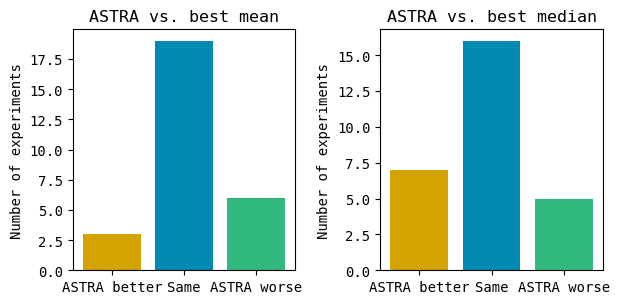

In [27]:
plot_astra_compare_results(
    mses_average=[
        LogD_random_mse_best_mean,
        LogD_butina_mse_best_mean,
        LogD_bemismurcko_mse_best_mean,
        LogD_kmeans_mse_best_mean,
        KSOL_random_mse_best_mean,
        KSOL_butina_mse_best_mean,
        KSOL_bemismurcko_mse_best_mean,
        KSOL_kmeans_mse_best_mean,
        HLM_random_mse_best_mean,
        HLM_butina_mse_best_mean,
        HLM_bemismurcko_mse_best_mean,
        HLM_kmeans_mse_best_mean,
        MDR1_MDCKII_random_mse_best_mean,
        MDR1_MDCKII_butina_mse_best_mean,
        MDR1_MDCKII_bemismurcko_mse_best_mean,
        MDR1_MDCKII_kmeans_mse_best_mean,
        MLM_random_mse_best_mean,
        MLM_butina_mse_best_mean,
        MLM_bemismurcko_mse_best_mean,
        MLM_kmeans_mse_best_mean,
        SARS_random_mse_best_mean,
        SARS_butina_mse_best_mean,
        SARS_bemismurcko_mse_best_mean,
        SARS_kmeans_mse_best_mean,
        MERS_random_mse_best_mean,
        MERS_butina_mse_best_mean,
        MERS_bemismurcko_mse_best_mean,
        MERS_kmeans_mse_best_mean,
    ],
    mses_median=[
        LogD_random_mse_best_median,
        LogD_butina_mse_best_median,
        LogD_bemismurcko_mse_best_median,
        LogD_kmeans_mse_best_median,
        KSOL_random_mse_best_median,
        KSOL_butina_mse_best_median,
        KSOL_bemismurcko_mse_best_median,
        KSOL_kmeans_mse_best_median,
        HLM_random_mse_best_median,
        HLM_butina_mse_best_median,
        HLM_bemismurcko_mse_best_median,
        HLM_kmeans_mse_best_median,
        MDR1_MDCKII_random_mse_best_median,
        MDR1_MDCKII_butina_mse_best_median,
        MDR1_MDCKII_bemismurcko_mse_best_median,
        MDR1_MDCKII_kmeans_mse_best_median,
        MLM_random_mse_best_median,
        MLM_butina_mse_best_median,
        MLM_bemismurcko_mse_best_median,
        MLM_kmeans_mse_best_median,
        SARS_random_mse_best_median,
        SARS_butina_mse_best_median,
        SARS_bemismurcko_mse_best_median,
        SARS_kmeans_mse_best_median,
        MERS_random_mse_best_median,
        MERS_butina_mse_best_median,
        MERS_bemismurcko_mse_best_median,
        MERS_kmeans_mse_best_median,
    ],
    mses_astra=[
        LogD_random_mse_astra,
        LogD_butina_mse_astra,
        LogD_bemismurcko_mse_astra,
        LogD_kmeans_mse_astra,
        KSOL_random_mse_astra,
        KSOL_butina_mse_astra,
        KSOL_bemismurcko_mse_astra,
        KSOL_kmeans_mse_astra,
        HLM_random_mse_astra,
        HLM_butina_mse_astra,
        HLM_bemismurcko_mse_astra,
        HLM_kmeans_mse_astra,
        MDR1_MDCKII_random_mse_astra,
        MDR1_MDCKII_butina_mse_astra,
        MDR1_MDCKII_bemismurcko_mse_astra,
        MDR1_MDCKII_kmeans_mse_astra,
        MLM_random_mse_astra,
        MLM_butina_mse_astra,
        MLM_bemismurcko_mse_astra,
        MLM_kmeans_mse_astra,
        SARS_random_mse_astra,
        SARS_butina_mse_astra,
        SARS_bemismurcko_mse_astra,
        SARS_kmeans_mse_astra,
        MERS_random_mse_astra,
        MERS_butina_mse_astra,
        MERS_bemismurcko_mse_astra,
        MERS_kmeans_mse_astra,
    ],
    pvals=[
        LogD_random_pvalue,
        LogD_butina_pvalue,
        LogD_bemismurcko_pvalue,
        LogD_kmeans_pvalue,
        KSOL_random_pvalue,
        KSOL_butina_pvalue,
        KSOL_bemismurcko_pvalue,
        KSOL_kmeans_pvalue,
        HLM_random_pvalue,
        HLM_butina_pvalue,
        HLM_bemismurcko_pvalue,
        HLM_kmeans_pvalue,
        MDR1_MDCKII_random_pvalue,
        MDR1_MDCKII_butina_pvalue,
        MDR1_MDCKII_bemismurcko_pvalue,
        MDR1_MDCKII_kmeans_pvalue,
        MLM_random_pvalue,
        MLM_butina_pvalue,
        MLM_bemismurcko_pvalue,
        MLM_kmeans_pvalue,
        SARS_random_pvalue,
        SARS_butina_pvalue,
        SARS_bemismurcko_pvalue,
        SARS_kmeans_pvalue,
        MERS_random_pvalue,
        MERS_butina_pvalue,
        MERS_bemismurcko_pvalue,
        MERS_kmeans_pvalue,
    ],
)

{'ASTRA better': 3, 'Same': 16, 'ASTRA worse': 5}
{'ASTRA better': 7, 'Same': 12, 'ASTRA worse': 5}


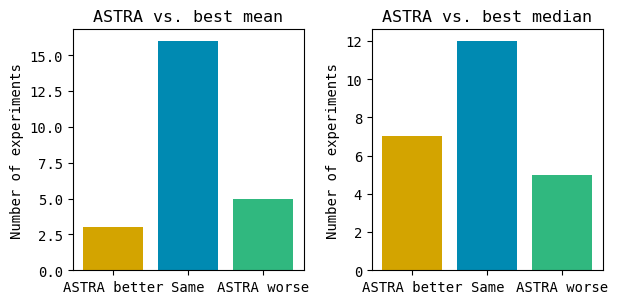

In [28]:
plot_astra_compare_results(
    mses_average=[
        LogD_random_mse_best_mean,
        LogD_butina_mse_best_mean,
        LogD_bemismurcko_mse_best_mean,
        LogD_kmeans_mse_best_mean,
        KSOL_random_mse_best_mean,
        KSOL_butina_mse_best_mean,
        KSOL_bemismurcko_mse_best_mean,
        KSOL_kmeans_mse_best_mean,
        HLM_random_mse_best_mean,
        HLM_butina_mse_best_mean,
        HLM_bemismurcko_mse_best_mean,
        HLM_kmeans_mse_best_mean,
        MDR1_MDCKII_random_mse_best_mean,
        MDR1_MDCKII_butina_mse_best_mean,
        MDR1_MDCKII_bemismurcko_mse_best_mean,
        MDR1_MDCKII_kmeans_mse_best_mean,
        MLM_random_mse_best_mean,
        MLM_butina_mse_best_mean,
        MLM_bemismurcko_mse_best_mean,
        MLM_kmeans_mse_best_mean,
        SARS_random_mse_best_mean,
        SARS_butina_mse_best_mean,
        SARS_bemismurcko_mse_best_mean,
        SARS_kmeans_mse_best_mean,
        MERS_random_mse_best_mean,
        MERS_butina_mse_best_mean,
        MERS_bemismurcko_mse_best_mean,
        MERS_kmeans_mse_best_mean,
    ],
    mses_median=[
        LogD_random_mse_best_median,
        LogD_butina_mse_best_median,
        LogD_bemismurcko_mse_best_median,
        LogD_kmeans_mse_best_median,
        KSOL_random_mse_best_median,
        KSOL_butina_mse_best_median,
        KSOL_bemismurcko_mse_best_median,
        KSOL_kmeans_mse_best_median,
        HLM_random_mse_best_median,
        HLM_butina_mse_best_median,
        HLM_bemismurcko_mse_best_median,
        HLM_kmeans_mse_best_median,
        MDR1_MDCKII_random_mse_best_median,
        MDR1_MDCKII_butina_mse_best_median,
        MDR1_MDCKII_bemismurcko_mse_best_median,
        MDR1_MDCKII_kmeans_mse_best_median,
        MLM_random_mse_best_median,
        MLM_butina_mse_best_median,
        MLM_bemismurcko_mse_best_median,
        MLM_kmeans_mse_best_median,
        SARS_random_mse_best_median,
        SARS_butina_mse_best_median,
        SARS_bemismurcko_mse_best_median,
        SARS_kmeans_mse_best_median,
        MERS_random_mse_best_median,
        MERS_butina_mse_best_median,
        MERS_bemismurcko_mse_best_median,
        MERS_kmeans_mse_best_median,
    ],
    mses_astra=[
        LogD_random_mse_astra,
        LogD_butina_mse_astra,
        LogD_bemismurcko_mse_astra,
        LogD_kmeans_mse_astra,
        KSOL_random_mse_astra,
        KSOL_butina_mse_astra,
        KSOL_bemismurcko_mse_astra,
        KSOL_kmeans_mse_astra,
        HLM_random_mse_astra,
        HLM_butina_mse_astra,
        HLM_bemismurcko_mse_astra,
        HLM_kmeans_mse_astra,
        MDR1_MDCKII_random_mse_astra,
        MDR1_MDCKII_butina_mse_astra,
        MDR1_MDCKII_bemismurcko_mse_astra,
        MDR1_MDCKII_kmeans_mse_astra,
        MLM_random_mse_astra,
        MLM_butina_mse_astra,
        MLM_bemismurcko_mse_astra,
        MLM_kmeans_mse_astra,
        SARS_random_mse_astra,
        SARS_butina_mse_astra,
        SARS_bemismurcko_mse_astra,
        SARS_kmeans_mse_astra,
        MERS_random_mse_astra,
        MERS_butina_mse_astra,
        MERS_bemismurcko_mse_astra,
        MERS_kmeans_mse_astra,
    ],
    pvals=[
        LogD_random_pvalue,
        LogD_butina_pvalue,
        LogD_bemismurcko_pvalue,
        LogD_kmeans_pvalue,
        KSOL_random_pvalue,
        KSOL_butina_pvalue,
        KSOL_bemismurcko_pvalue,
        KSOL_kmeans_pvalue,
        HLM_random_pvalue,
        HLM_butina_pvalue,
        HLM_bemismurcko_pvalue,
        HLM_kmeans_pvalue,
        MDR1_MDCKII_random_pvalue,
        MDR1_MDCKII_butina_pvalue,
        MDR1_MDCKII_bemismurcko_pvalue,
        MDR1_MDCKII_kmeans_pvalue,
        MLM_random_pvalue,
        MLM_butina_pvalue,
        MLM_bemismurcko_pvalue,
        MLM_kmeans_pvalue,
        SARS_random_pvalue,
        SARS_butina_pvalue,
        SARS_bemismurcko_pvalue,
        SARS_kmeans_pvalue,
        MERS_random_pvalue,
        MERS_butina_pvalue,
        MERS_bemismurcko_pvalue,
        MERS_kmeans_pvalue,
    ],
    subset="insignificant",
)

{'ASTRA better': 0, 'Same': 3, 'ASTRA worse': 1}
{'ASTRA better': 0, 'Same': 4, 'ASTRA worse': 0}


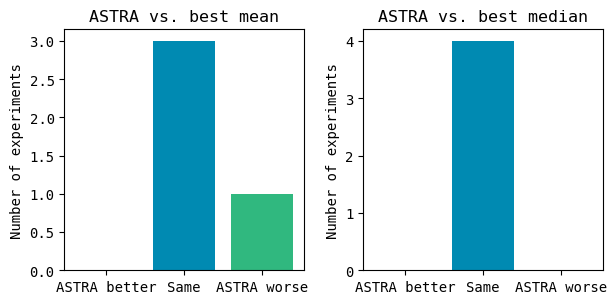

In [29]:
plot_astra_compare_results(
    mses_average=[
        LogD_random_mse_best_mean,
        LogD_butina_mse_best_mean,
        LogD_bemismurcko_mse_best_mean,
        LogD_kmeans_mse_best_mean,
        KSOL_random_mse_best_mean,
        KSOL_butina_mse_best_mean,
        KSOL_bemismurcko_mse_best_mean,
        KSOL_kmeans_mse_best_mean,
        HLM_random_mse_best_mean,
        HLM_butina_mse_best_mean,
        HLM_bemismurcko_mse_best_mean,
        HLM_kmeans_mse_best_mean,
        MDR1_MDCKII_random_mse_best_mean,
        MDR1_MDCKII_butina_mse_best_mean,
        MDR1_MDCKII_bemismurcko_mse_best_mean,
        MDR1_MDCKII_kmeans_mse_best_mean,
        MLM_random_mse_best_mean,
        MLM_butina_mse_best_mean,
        MLM_bemismurcko_mse_best_mean,
        MLM_kmeans_mse_best_mean,
        SARS_random_mse_best_mean,
        SARS_butina_mse_best_mean,
        SARS_bemismurcko_mse_best_mean,
        SARS_kmeans_mse_best_mean,
        MERS_random_mse_best_mean,
        MERS_butina_mse_best_mean,
        MERS_bemismurcko_mse_best_mean,
        MERS_kmeans_mse_best_mean,
    ],
    mses_median=[
        LogD_random_mse_best_median,
        LogD_butina_mse_best_median,
        LogD_bemismurcko_mse_best_median,
        LogD_kmeans_mse_best_median,
        KSOL_random_mse_best_median,
        KSOL_butina_mse_best_median,
        KSOL_bemismurcko_mse_best_median,
        KSOL_kmeans_mse_best_median,
        HLM_random_mse_best_median,
        HLM_butina_mse_best_median,
        HLM_bemismurcko_mse_best_median,
        HLM_kmeans_mse_best_median,
        MDR1_MDCKII_random_mse_best_median,
        MDR1_MDCKII_butina_mse_best_median,
        MDR1_MDCKII_bemismurcko_mse_best_median,
        MDR1_MDCKII_kmeans_mse_best_median,
        MLM_random_mse_best_median,
        MLM_butina_mse_best_median,
        MLM_bemismurcko_mse_best_median,
        MLM_kmeans_mse_best_median,
        SARS_random_mse_best_median,
        SARS_butina_mse_best_median,
        SARS_bemismurcko_mse_best_median,
        SARS_kmeans_mse_best_median,
        MERS_random_mse_best_median,
        MERS_butina_mse_best_median,
        MERS_bemismurcko_mse_best_median,
        MERS_kmeans_mse_best_median,
    ],
    mses_astra=[
        LogD_random_mse_astra,
        LogD_butina_mse_astra,
        LogD_bemismurcko_mse_astra,
        LogD_kmeans_mse_astra,
        KSOL_random_mse_astra,
        KSOL_butina_mse_astra,
        KSOL_bemismurcko_mse_astra,
        KSOL_kmeans_mse_astra,
        HLM_random_mse_astra,
        HLM_butina_mse_astra,
        HLM_bemismurcko_mse_astra,
        HLM_kmeans_mse_astra,
        MDR1_MDCKII_random_mse_astra,
        MDR1_MDCKII_butina_mse_astra,
        MDR1_MDCKII_bemismurcko_mse_astra,
        MDR1_MDCKII_kmeans_mse_astra,
        MLM_random_mse_astra,
        MLM_butina_mse_astra,
        MLM_bemismurcko_mse_astra,
        MLM_kmeans_mse_astra,
        SARS_random_mse_astra,
        SARS_butina_mse_astra,
        SARS_bemismurcko_mse_astra,
        SARS_kmeans_mse_astra,
        MERS_random_mse_astra,
        MERS_butina_mse_astra,
        MERS_bemismurcko_mse_astra,
        MERS_kmeans_mse_astra,
    ],
    pvals=[
        LogD_random_pvalue,
        LogD_butina_pvalue,
        LogD_bemismurcko_pvalue,
        LogD_kmeans_pvalue,
        KSOL_random_pvalue,
        KSOL_butina_pvalue,
        KSOL_bemismurcko_pvalue,
        KSOL_kmeans_pvalue,
        HLM_random_pvalue,
        HLM_butina_pvalue,
        HLM_bemismurcko_pvalue,
        HLM_kmeans_pvalue,
        MDR1_MDCKII_random_pvalue,
        MDR1_MDCKII_butina_pvalue,
        MDR1_MDCKII_bemismurcko_pvalue,
        MDR1_MDCKII_kmeans_pvalue,
        MLM_random_pvalue,
        MLM_butina_pvalue,
        MLM_bemismurcko_pvalue,
        MLM_kmeans_pvalue,
        SARS_random_pvalue,
        SARS_butina_pvalue,
        SARS_bemismurcko_pvalue,
        SARS_kmeans_pvalue,
        MERS_random_pvalue,
        MERS_butina_pvalue,
        MERS_bemismurcko_pvalue,
        MERS_kmeans_pvalue,
    ],
    subset="significant",
)

{'Gains': 21.79035479625452, 'Losses': -22.050904858674386, 'Total': -2.3905130272600985}
{'Gains': 11.291740505252656, 'Losses': -17.716331667816394, 'Total': -0.3406955286540491}
One-sided (alternative: less) Wilcoxon signed-rank test (mean): p-value=0.8040483093731778
One-sided (alternative: less) Wilcoxon signed-rank test (median): p-value=0.3331705701561999
One-sided (alternative: greater) Wilcoxon signed-rank test (mean): p-value=0.19595169062682216
One-sided (alternative: greater) Wilcoxon signed-rank test (median): p-value=0.6668294298438001
Regular Wilcoxon signed-rank test (mean): p-value=0.3919033812536443
Regular Wilcoxon signed-rank test (median): p-value=0.6663411403123998


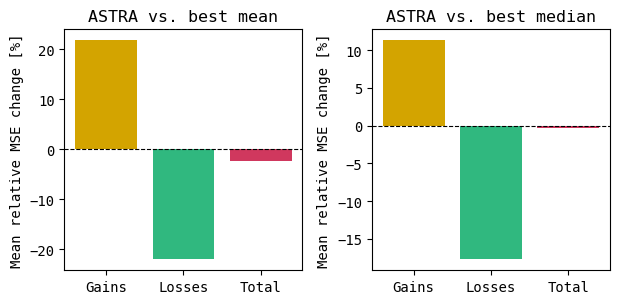

In [30]:
plot_astra_compare_results_quantitative(
    mses_average=[
        LogD_random_mse_best_mean,
        LogD_butina_mse_best_mean,
        LogD_bemismurcko_mse_best_mean,
        LogD_kmeans_mse_best_mean,
        KSOL_random_mse_best_mean,
        KSOL_butina_mse_best_mean,
        KSOL_bemismurcko_mse_best_mean,
        KSOL_kmeans_mse_best_mean,
        HLM_random_mse_best_mean,
        HLM_butina_mse_best_mean,
        HLM_bemismurcko_mse_best_mean,
        HLM_kmeans_mse_best_mean,
        MDR1_MDCKII_random_mse_best_mean,
        MDR1_MDCKII_butina_mse_best_mean,
        MDR1_MDCKII_bemismurcko_mse_best_mean,
        MDR1_MDCKII_kmeans_mse_best_mean,
        MLM_random_mse_best_mean,
        MLM_butina_mse_best_mean,
        MLM_bemismurcko_mse_best_mean,
        MLM_kmeans_mse_best_mean,
        SARS_random_mse_best_mean,
        SARS_butina_mse_best_mean,
        SARS_bemismurcko_mse_best_mean,
        SARS_kmeans_mse_best_mean,
        MERS_random_mse_best_mean,
        MERS_butina_mse_best_mean,
        MERS_bemismurcko_mse_best_mean,
        MERS_kmeans_mse_best_mean,
    ],
    mses_median=[
        LogD_random_mse_best_median,
        LogD_butina_mse_best_median,
        LogD_bemismurcko_mse_best_median,
        LogD_kmeans_mse_best_median,
        KSOL_random_mse_best_median,
        KSOL_butina_mse_best_median,
        KSOL_bemismurcko_mse_best_median,
        KSOL_kmeans_mse_best_median,
        HLM_random_mse_best_median,
        HLM_butina_mse_best_median,
        HLM_bemismurcko_mse_best_median,
        HLM_kmeans_mse_best_median,
        MDR1_MDCKII_random_mse_best_median,
        MDR1_MDCKII_butina_mse_best_median,
        MDR1_MDCKII_bemismurcko_mse_best_median,
        MDR1_MDCKII_kmeans_mse_best_median,
        MLM_random_mse_best_median,
        MLM_butina_mse_best_median,
        MLM_bemismurcko_mse_best_median,
        MLM_kmeans_mse_best_median,
        SARS_random_mse_best_median,
        SARS_butina_mse_best_median,
        SARS_bemismurcko_mse_best_median,
        SARS_kmeans_mse_best_median,
        MERS_random_mse_best_median,
        MERS_butina_mse_best_median,
        MERS_bemismurcko_mse_best_median,
        MERS_kmeans_mse_best_median,
    ],
    mses_astra=[
        LogD_random_mse_astra,
        LogD_butina_mse_astra,
        LogD_bemismurcko_mse_astra,
        LogD_kmeans_mse_astra,
        KSOL_random_mse_astra,
        KSOL_butina_mse_astra,
        KSOL_bemismurcko_mse_astra,
        KSOL_kmeans_mse_astra,
        HLM_random_mse_astra,
        HLM_butina_mse_astra,
        HLM_bemismurcko_mse_astra,
        HLM_kmeans_mse_astra,
        MDR1_MDCKII_random_mse_astra,
        MDR1_MDCKII_butina_mse_astra,
        MDR1_MDCKII_bemismurcko_mse_astra,
        MDR1_MDCKII_kmeans_mse_astra,
        MLM_random_mse_astra,
        MLM_butina_mse_astra,
        MLM_bemismurcko_mse_astra,
        MLM_kmeans_mse_astra,
        SARS_random_mse_astra,
        SARS_butina_mse_astra,
        SARS_bemismurcko_mse_astra,
        SARS_kmeans_mse_astra,
        MERS_random_mse_astra,
        MERS_butina_mse_astra,
        MERS_bemismurcko_mse_astra,
        MERS_kmeans_mse_astra,
    ],
    pvals=[
        LogD_random_pvalue,
        LogD_butina_pvalue,
        LogD_bemismurcko_pvalue,
        LogD_kmeans_pvalue,
        KSOL_random_pvalue,
        KSOL_butina_pvalue,
        KSOL_bemismurcko_pvalue,
        KSOL_kmeans_pvalue,
        HLM_random_pvalue,
        HLM_butina_pvalue,
        HLM_bemismurcko_pvalue,
        HLM_kmeans_pvalue,
        MDR1_MDCKII_random_pvalue,
        MDR1_MDCKII_butina_pvalue,
        MDR1_MDCKII_bemismurcko_pvalue,
        MDR1_MDCKII_kmeans_pvalue,
        MLM_random_pvalue,
        MLM_butina_pvalue,
        MLM_bemismurcko_pvalue,
        MLM_kmeans_pvalue,
        SARS_random_pvalue,
        SARS_butina_pvalue,
        SARS_bemismurcko_pvalue,
        SARS_kmeans_pvalue,
        MERS_random_pvalue,
        MERS_butina_pvalue,
        MERS_bemismurcko_pvalue,
        MERS_kmeans_pvalue,
    ],
)

{'Gains': 21.79035479625452, 'Losses': -22.126019059610222, 'Total': -1.885792954553648}
{'Gains': 11.291740505252656, 'Losses': -17.716331667816394, 'Total': -0.3974781167630573}
One-sided (alternative: less) Wilcoxon signed-rank test (mean): p-value=0.719970035500643
One-sided (alternative: less) Wilcoxon signed-rank test (median): p-value=0.34501225856458767
One-sided (alternative: greater) Wilcoxon signed-rank test (mean): p-value=0.280029964499357
One-sided (alternative: greater) Wilcoxon signed-rank test (median): p-value=0.6549877414354124
Regular Wilcoxon signed-rank test (mean): p-value=0.560059928998714
Regular Wilcoxon signed-rank test (median): p-value=0.6900245171291753


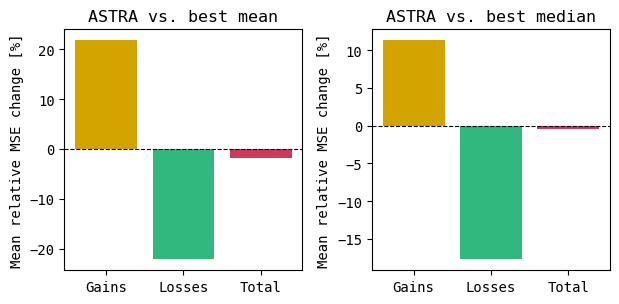

In [31]:
plot_astra_compare_results_quantitative(
    mses_average=[
        LogD_random_mse_best_mean,
        LogD_butina_mse_best_mean,
        LogD_bemismurcko_mse_best_mean,
        LogD_kmeans_mse_best_mean,
        KSOL_random_mse_best_mean,
        KSOL_butina_mse_best_mean,
        KSOL_bemismurcko_mse_best_mean,
        KSOL_kmeans_mse_best_mean,
        HLM_random_mse_best_mean,
        HLM_butina_mse_best_mean,
        HLM_bemismurcko_mse_best_mean,
        HLM_kmeans_mse_best_mean,
        MDR1_MDCKII_random_mse_best_mean,
        MDR1_MDCKII_butina_mse_best_mean,
        MDR1_MDCKII_bemismurcko_mse_best_mean,
        MDR1_MDCKII_kmeans_mse_best_mean,
        MLM_random_mse_best_mean,
        MLM_butina_mse_best_mean,
        MLM_bemismurcko_mse_best_mean,
        MLM_kmeans_mse_best_mean,
        SARS_random_mse_best_mean,
        SARS_butina_mse_best_mean,
        SARS_bemismurcko_mse_best_mean,
        SARS_kmeans_mse_best_mean,
        MERS_random_mse_best_mean,
        MERS_butina_mse_best_mean,
        MERS_bemismurcko_mse_best_mean,
        MERS_kmeans_mse_best_mean,
    ],
    mses_median=[
        LogD_random_mse_best_median,
        LogD_butina_mse_best_median,
        LogD_bemismurcko_mse_best_median,
        LogD_kmeans_mse_best_median,
        KSOL_random_mse_best_median,
        KSOL_butina_mse_best_median,
        KSOL_bemismurcko_mse_best_median,
        KSOL_kmeans_mse_best_median,
        HLM_random_mse_best_median,
        HLM_butina_mse_best_median,
        HLM_bemismurcko_mse_best_median,
        HLM_kmeans_mse_best_median,
        MDR1_MDCKII_random_mse_best_median,
        MDR1_MDCKII_butina_mse_best_median,
        MDR1_MDCKII_bemismurcko_mse_best_median,
        MDR1_MDCKII_kmeans_mse_best_median,
        MLM_random_mse_best_median,
        MLM_butina_mse_best_median,
        MLM_bemismurcko_mse_best_median,
        MLM_kmeans_mse_best_median,
        SARS_random_mse_best_median,
        SARS_butina_mse_best_median,
        SARS_bemismurcko_mse_best_median,
        SARS_kmeans_mse_best_median,
        MERS_random_mse_best_median,
        MERS_butina_mse_best_median,
        MERS_bemismurcko_mse_best_median,
        MERS_kmeans_mse_best_median,
    ],
    mses_astra=[
        LogD_random_mse_astra,
        LogD_butina_mse_astra,
        LogD_bemismurcko_mse_astra,
        LogD_kmeans_mse_astra,
        KSOL_random_mse_astra,
        KSOL_butina_mse_astra,
        KSOL_bemismurcko_mse_astra,
        KSOL_kmeans_mse_astra,
        HLM_random_mse_astra,
        HLM_butina_mse_astra,
        HLM_bemismurcko_mse_astra,
        HLM_kmeans_mse_astra,
        MDR1_MDCKII_random_mse_astra,
        MDR1_MDCKII_butina_mse_astra,
        MDR1_MDCKII_bemismurcko_mse_astra,
        MDR1_MDCKII_kmeans_mse_astra,
        MLM_random_mse_astra,
        MLM_butina_mse_astra,
        MLM_bemismurcko_mse_astra,
        MLM_kmeans_mse_astra,
        SARS_random_mse_astra,
        SARS_butina_mse_astra,
        SARS_bemismurcko_mse_astra,
        SARS_kmeans_mse_astra,
        MERS_random_mse_astra,
        MERS_butina_mse_astra,
        MERS_bemismurcko_mse_astra,
        MERS_kmeans_mse_astra,
    ],
    pvals=[
        LogD_random_pvalue,
        LogD_butina_pvalue,
        LogD_bemismurcko_pvalue,
        LogD_kmeans_pvalue,
        KSOL_random_pvalue,
        KSOL_butina_pvalue,
        KSOL_bemismurcko_pvalue,
        KSOL_kmeans_pvalue,
        HLM_random_pvalue,
        HLM_butina_pvalue,
        HLM_bemismurcko_pvalue,
        HLM_kmeans_pvalue,
        MDR1_MDCKII_random_pvalue,
        MDR1_MDCKII_butina_pvalue,
        MDR1_MDCKII_bemismurcko_pvalue,
        MDR1_MDCKII_kmeans_pvalue,
        MLM_random_pvalue,
        MLM_butina_pvalue,
        MLM_bemismurcko_pvalue,
        MLM_kmeans_pvalue,
        SARS_random_pvalue,
        SARS_butina_pvalue,
        SARS_bemismurcko_pvalue,
        SARS_kmeans_pvalue,
        MERS_random_pvalue,
        MERS_butina_pvalue,
        MERS_bemismurcko_pvalue,
        MERS_kmeans_pvalue,
    ],
    subset="insignificant",
)

{'Gains': 0, 'Losses': -21.67533385399519, 'Total': -5.418833463498798}
{'Gains': 0, 'Losses': 0, 'Total': 0.0}
One-sided (alternative: less) Wilcoxon signed-rank test (mean): p-value=1.0
One-sided (alternative: less) Wilcoxon signed-rank test (median): p-value=1.0
One-sided (alternative: greater) Wilcoxon signed-rank test (mean): p-value=0.5
One-sided (alternative: greater) Wilcoxon signed-rank test (median): p-value=1.0
Regular Wilcoxon signed-rank test (mean): p-value=1.0
Regular Wilcoxon signed-rank test (median): p-value=1.0


/u/fd/sjoh5775/miniconda3/envs/astra_benchmark/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


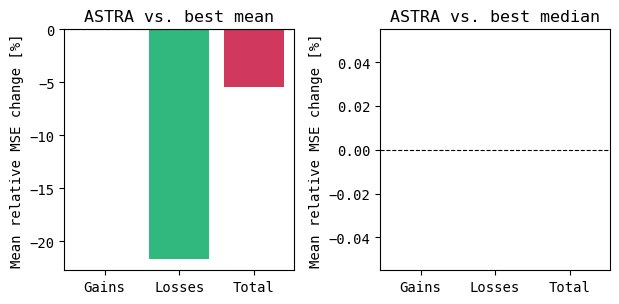

In [32]:
plot_astra_compare_results_quantitative(
    mses_average=[
        LogD_random_mse_best_mean,
        LogD_butina_mse_best_mean,
        LogD_bemismurcko_mse_best_mean,
        LogD_kmeans_mse_best_mean,
        KSOL_random_mse_best_mean,
        KSOL_butina_mse_best_mean,
        KSOL_bemismurcko_mse_best_mean,
        KSOL_kmeans_mse_best_mean,
        HLM_random_mse_best_mean,
        HLM_butina_mse_best_mean,
        HLM_bemismurcko_mse_best_mean,
        HLM_kmeans_mse_best_mean,
        MDR1_MDCKII_random_mse_best_mean,
        MDR1_MDCKII_butina_mse_best_mean,
        MDR1_MDCKII_bemismurcko_mse_best_mean,
        MDR1_MDCKII_kmeans_mse_best_mean,
        MLM_random_mse_best_mean,
        MLM_butina_mse_best_mean,
        MLM_bemismurcko_mse_best_mean,
        MLM_kmeans_mse_best_mean,
        SARS_random_mse_best_mean,
        SARS_butina_mse_best_mean,
        SARS_bemismurcko_mse_best_mean,
        SARS_kmeans_mse_best_mean,
        MERS_random_mse_best_mean,
        MERS_butina_mse_best_mean,
        MERS_bemismurcko_mse_best_mean,
        MERS_kmeans_mse_best_mean,
    ],
    mses_median=[
        LogD_random_mse_best_median,
        LogD_butina_mse_best_median,
        LogD_bemismurcko_mse_best_median,
        LogD_kmeans_mse_best_median,
        KSOL_random_mse_best_median,
        KSOL_butina_mse_best_median,
        KSOL_bemismurcko_mse_best_median,
        KSOL_kmeans_mse_best_median,
        HLM_random_mse_best_median,
        HLM_butina_mse_best_median,
        HLM_bemismurcko_mse_best_median,
        HLM_kmeans_mse_best_median,
        MDR1_MDCKII_random_mse_best_median,
        MDR1_MDCKII_butina_mse_best_median,
        MDR1_MDCKII_bemismurcko_mse_best_median,
        MDR1_MDCKII_kmeans_mse_best_median,
        MLM_random_mse_best_median,
        MLM_butina_mse_best_median,
        MLM_bemismurcko_mse_best_median,
        MLM_kmeans_mse_best_median,
        SARS_random_mse_best_median,
        SARS_butina_mse_best_median,
        SARS_bemismurcko_mse_best_median,
        SARS_kmeans_mse_best_median,
        MERS_random_mse_best_median,
        MERS_butina_mse_best_median,
        MERS_bemismurcko_mse_best_median,
        MERS_kmeans_mse_best_median,
    ],
    mses_astra=[
        LogD_random_mse_astra,
        LogD_butina_mse_astra,
        LogD_bemismurcko_mse_astra,
        LogD_kmeans_mse_astra,
        KSOL_random_mse_astra,
        KSOL_butina_mse_astra,
        KSOL_bemismurcko_mse_astra,
        KSOL_kmeans_mse_astra,
        HLM_random_mse_astra,
        HLM_butina_mse_astra,
        HLM_bemismurcko_mse_astra,
        HLM_kmeans_mse_astra,
        MDR1_MDCKII_random_mse_astra,
        MDR1_MDCKII_butina_mse_astra,
        MDR1_MDCKII_bemismurcko_mse_astra,
        MDR1_MDCKII_kmeans_mse_astra,
        MLM_random_mse_astra,
        MLM_butina_mse_astra,
        MLM_bemismurcko_mse_astra,
        MLM_kmeans_mse_astra,
        SARS_random_mse_astra,
        SARS_butina_mse_astra,
        SARS_bemismurcko_mse_astra,
        SARS_kmeans_mse_astra,
        MERS_random_mse_astra,
        MERS_butina_mse_astra,
        MERS_bemismurcko_mse_astra,
        MERS_kmeans_mse_astra,
    ],
    pvals=[
        LogD_random_pvalue,
        LogD_butina_pvalue,
        LogD_bemismurcko_pvalue,
        LogD_kmeans_pvalue,
        KSOL_random_pvalue,
        KSOL_butina_pvalue,
        KSOL_bemismurcko_pvalue,
        KSOL_kmeans_pvalue,
        HLM_random_pvalue,
        HLM_butina_pvalue,
        HLM_bemismurcko_pvalue,
        HLM_kmeans_pvalue,
        MDR1_MDCKII_random_pvalue,
        MDR1_MDCKII_butina_pvalue,
        MDR1_MDCKII_bemismurcko_pvalue,
        MDR1_MDCKII_kmeans_pvalue,
        MLM_random_pvalue,
        MLM_butina_pvalue,
        MLM_bemismurcko_pvalue,
        MLM_kmeans_pvalue,
        SARS_random_pvalue,
        SARS_butina_pvalue,
        SARS_bemismurcko_pvalue,
        SARS_kmeans_pvalue,
        MERS_random_pvalue,
        MERS_butina_pvalue,
        MERS_bemismurcko_pvalue,
        MERS_kmeans_pvalue,
    ],
    subset="significant",
)

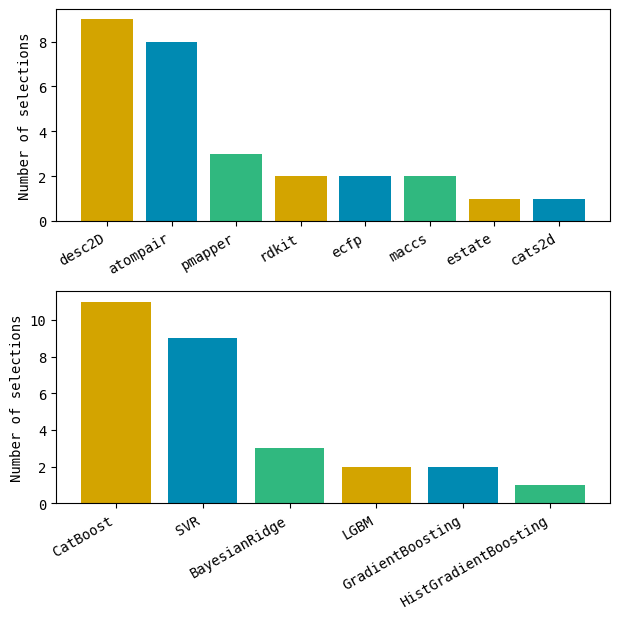

In [33]:
plot_fps_models(selected_fingerprints, selected_models)